# BKG Sample

### Created by Shu, 

#### Dataset recording (2025 Official MC Production):

pos1GeV:        'run20250613':  

pos5GeV:        'run20250623':  

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

#### No Space Cut; MS & MH cuts applied---

In [1]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc_bkg",
        "dates": [
            "pos1GeV_part1", "pos1GeV_part2", "pos1GeV_part3",
            "pos5GeV_part1", "pos5GeV_part2", "pos5GeV_part3"
        ]
    }
]

# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}  # initialize empty lists for each field

for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_bkg_{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")

print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))




[INFO] Reading group: ./statResult_tpc_bkg
  - Loaded 148509 entries from pos1GeV_part1 → appended to decayX_initial
  - Loaded 149221 entries from pos1GeV_part2 → appended to decayX_initial
  - Loaded  90522 entries from pos1GeV_part3 → appended to decayX_initial
  - Loaded 144553 entries from pos5GeV_part1 → appended to decayX_initial
  - Loaded 144600 entries from pos5GeV_part2 → appended to decayX_initial
  - Loaded  82474 entries from pos5GeV_part3 → appended to decayX_initial
  - Loaded 148509 entries from pos1GeV_part1 → appended to decayY_initial
  - Loaded 149221 entries from pos1GeV_part2 → appended to decayY_initial
  - Loaded  90522 entries from pos1GeV_part3 → appended to decayY_initial
  - Loaded 144553 entries from pos5GeV_part1 → appended to decayY_initial
  - Loaded 144600 entries from pos5GeV_part2 → appended to decayY_initial
  - Loaded  82474 entries from pos5GeV_part3 → appended to decayY_initial
  - Loaded 148509 entries from pos1GeV_part1 → appended to decayZ_in


Decay points distribution: 
# of X < 0 :  350631 (46.14%)
# of X >= 0:  409248 (53.86%)


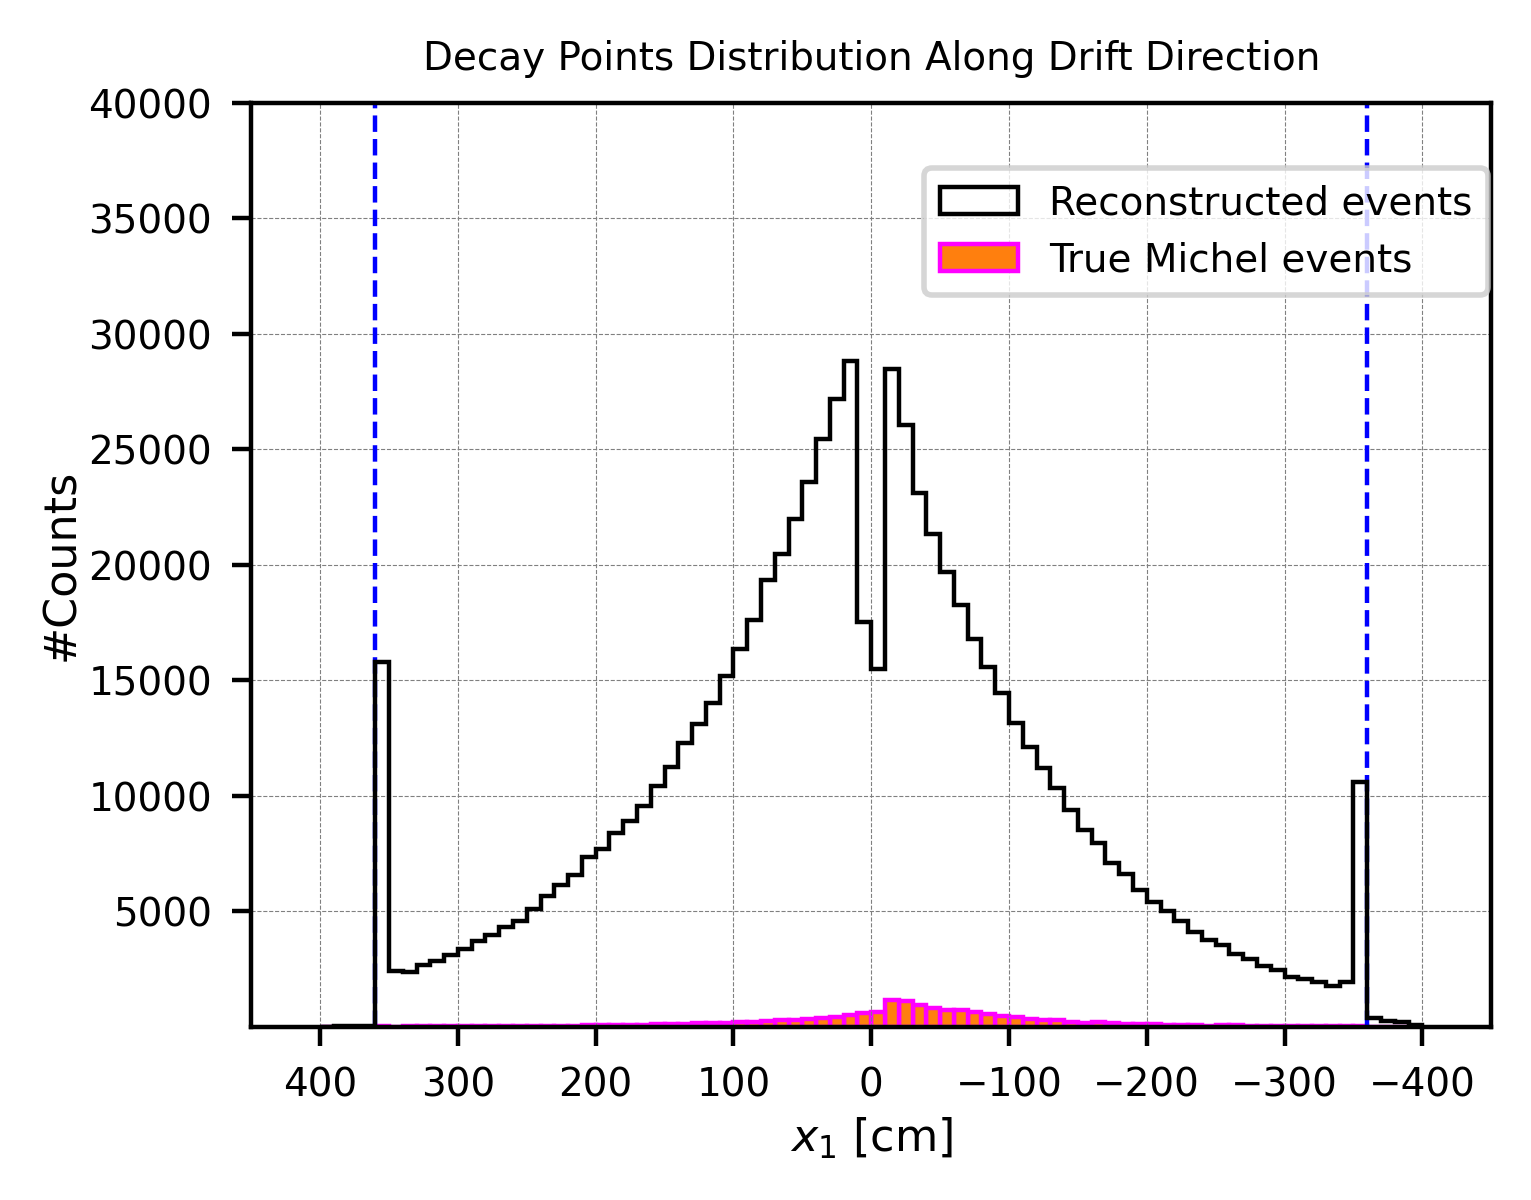

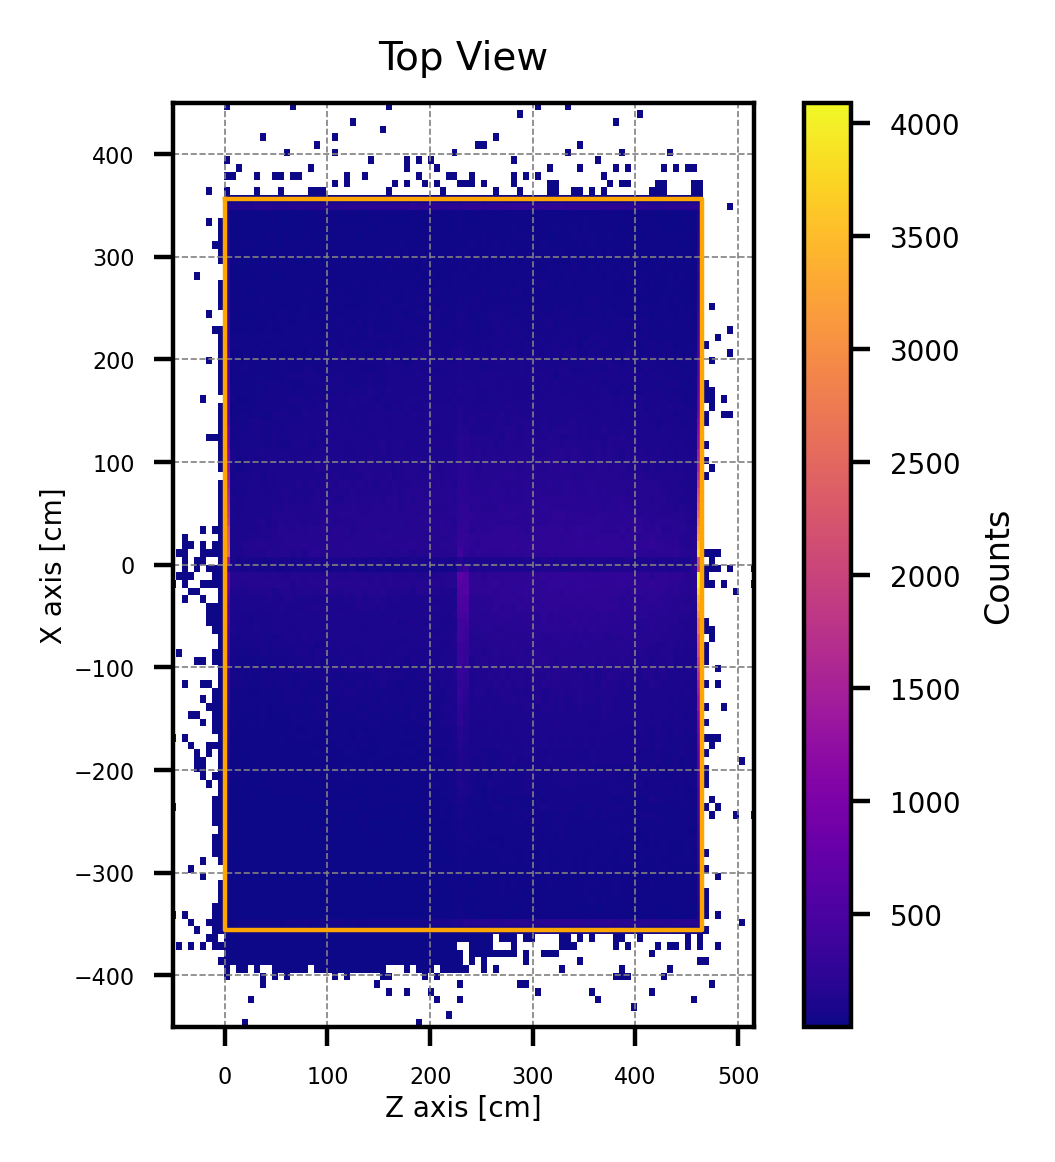

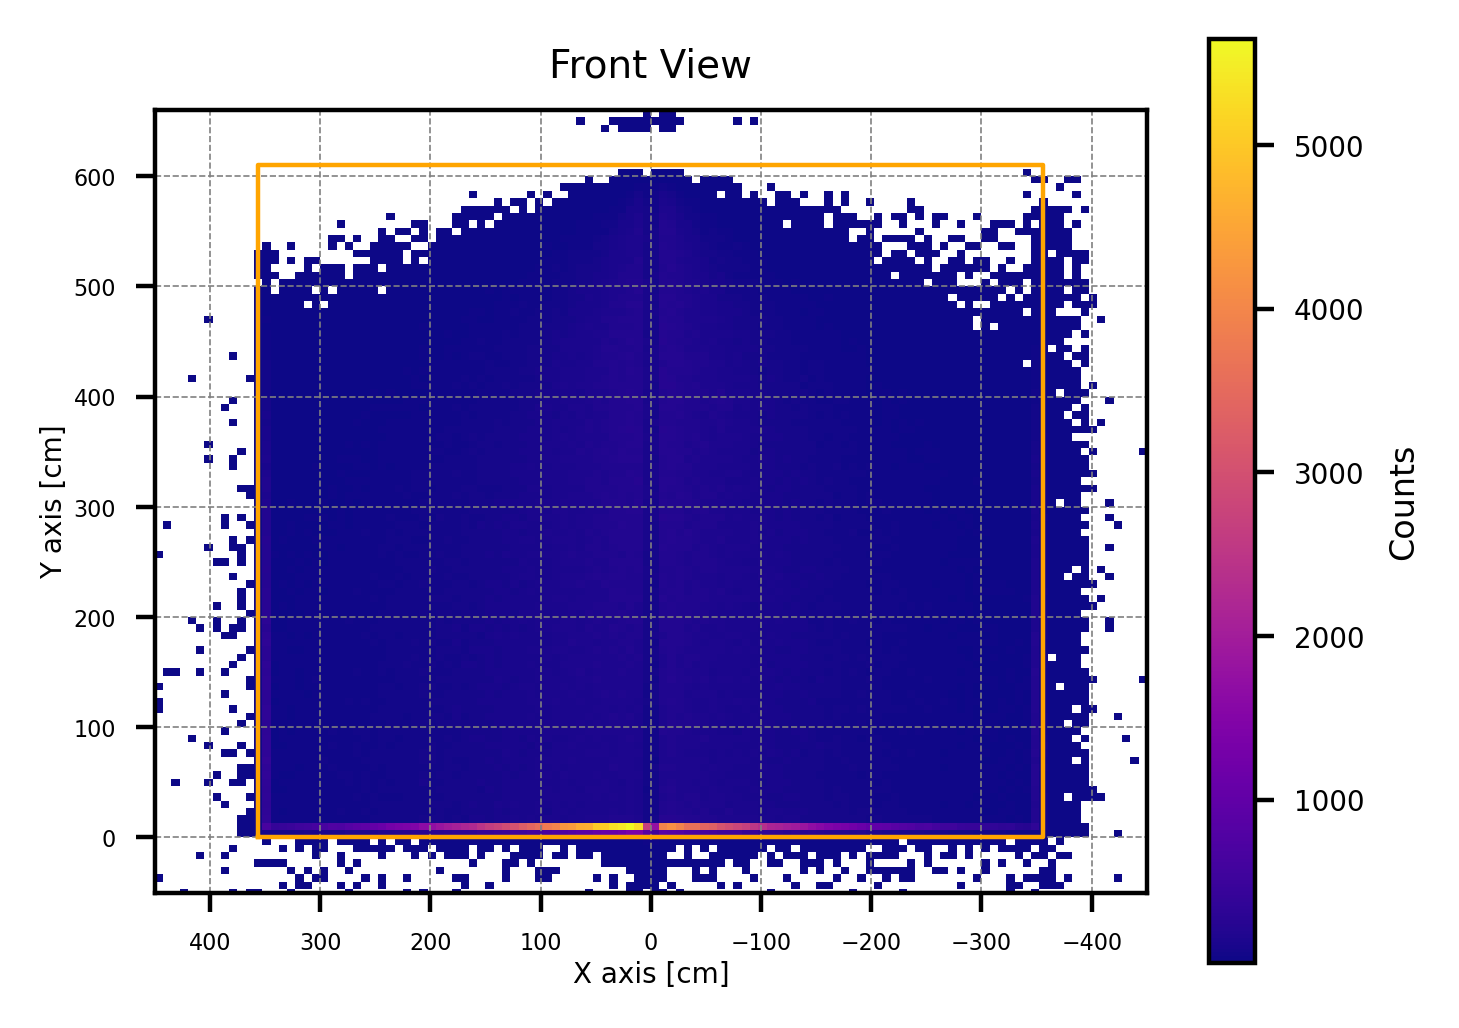

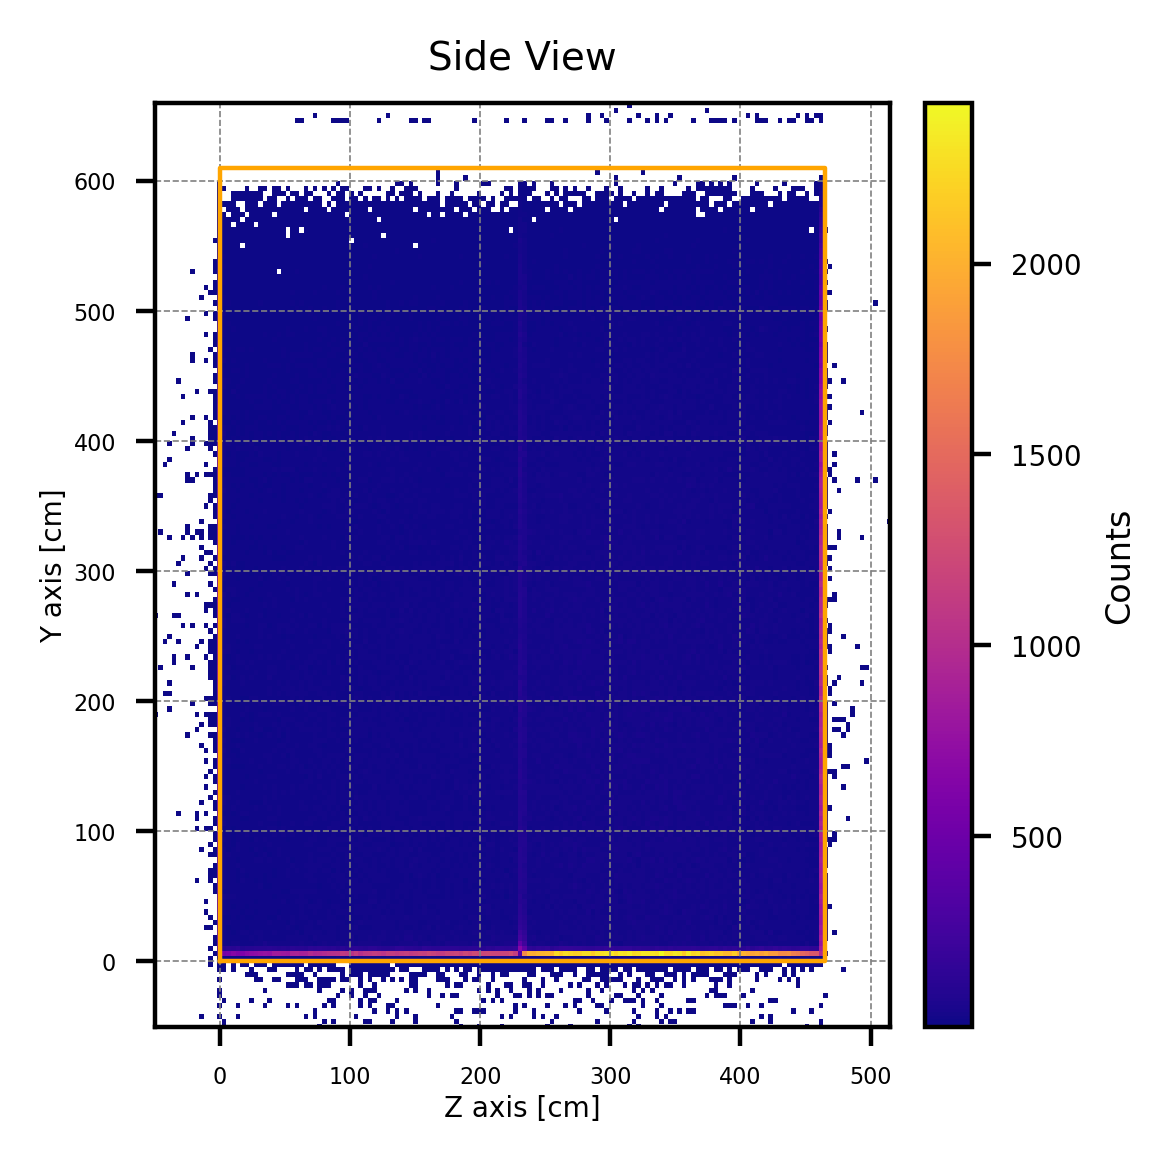


min(vals_MS_initial) 0.0
MS>0.1:  0


<Figure size 1600x1200 with 0 Axes>

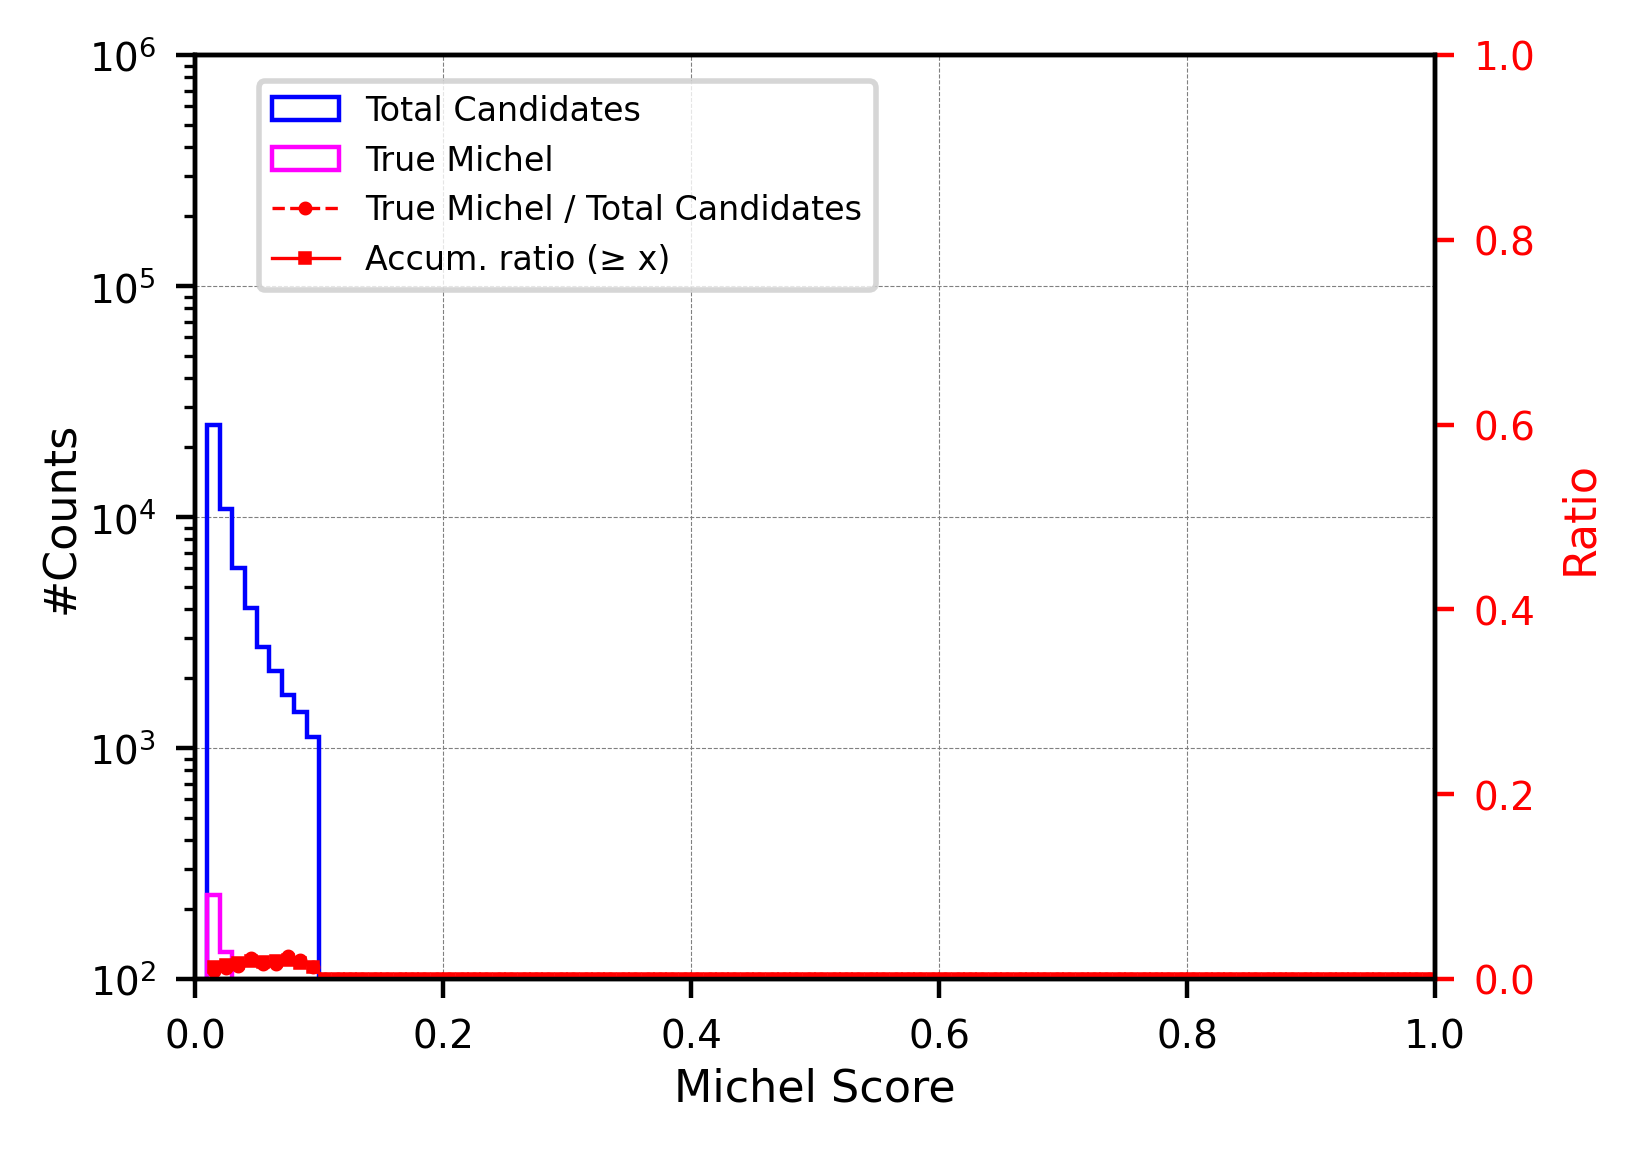

<Figure size 1600x1200 with 0 Axes>

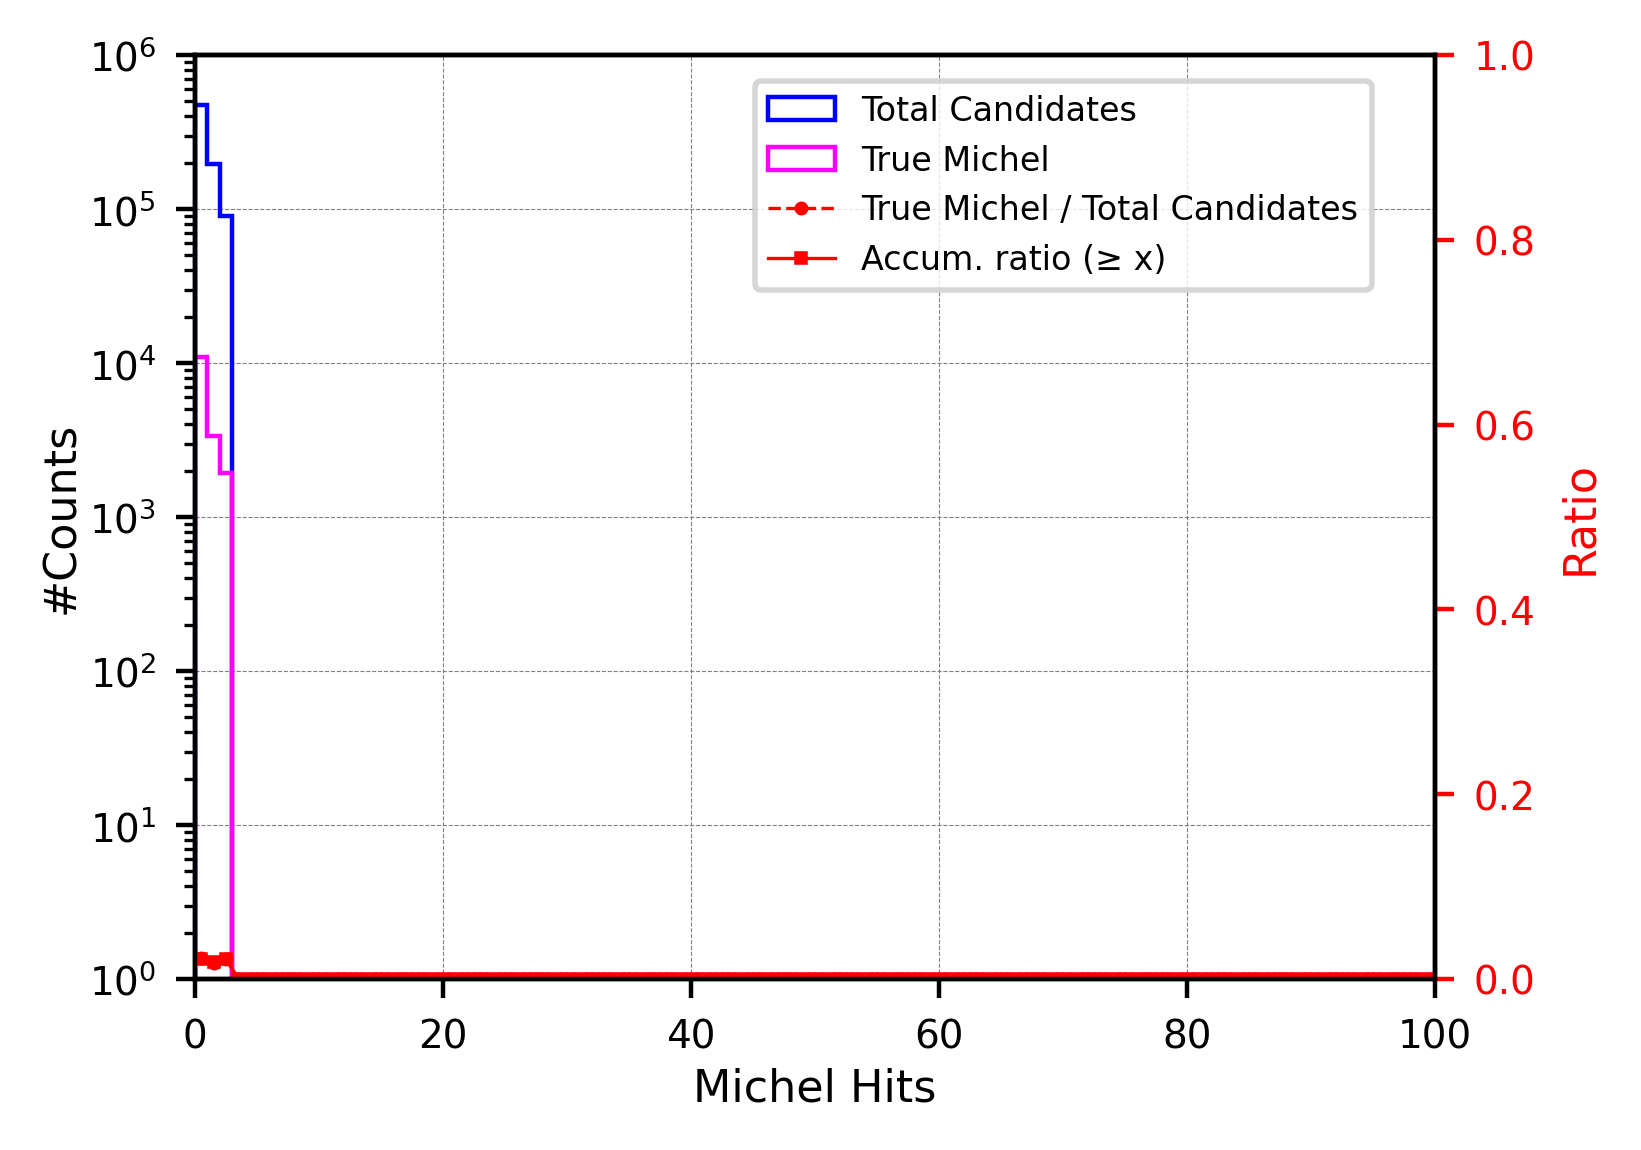

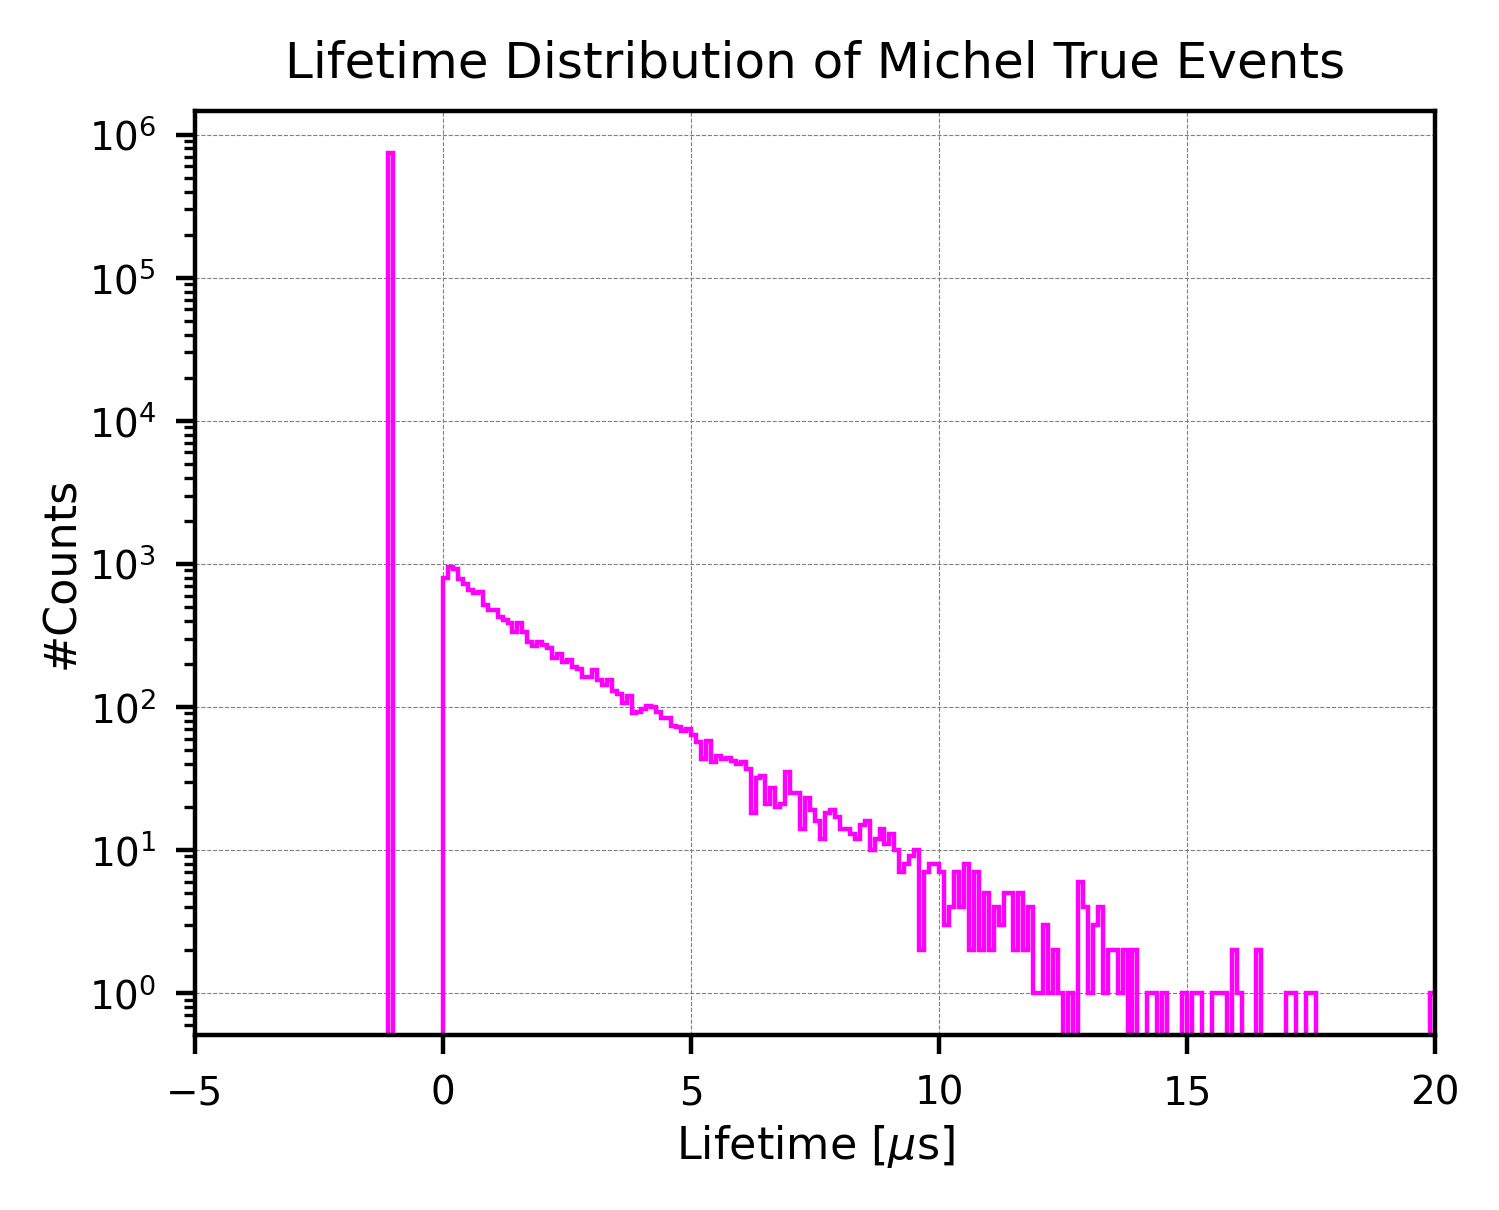

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_startX_initial = [ev.startX_initial for ev in events_reco]
vals_startY_initial = [ev.startY_initial for ev in events_reco]
vals_startZ_initial = [ev.startZ_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 40000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 40000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 40000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x > 0.1)
print("MS>0.1: ", count)



# Define the range and bin width
bin_width = 0.01
range_min = 0.01 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0.0, 1.0) #(-0.02, 1.02)
ax1.set_ylim(100, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.00)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









#### Distribution of Starting Point

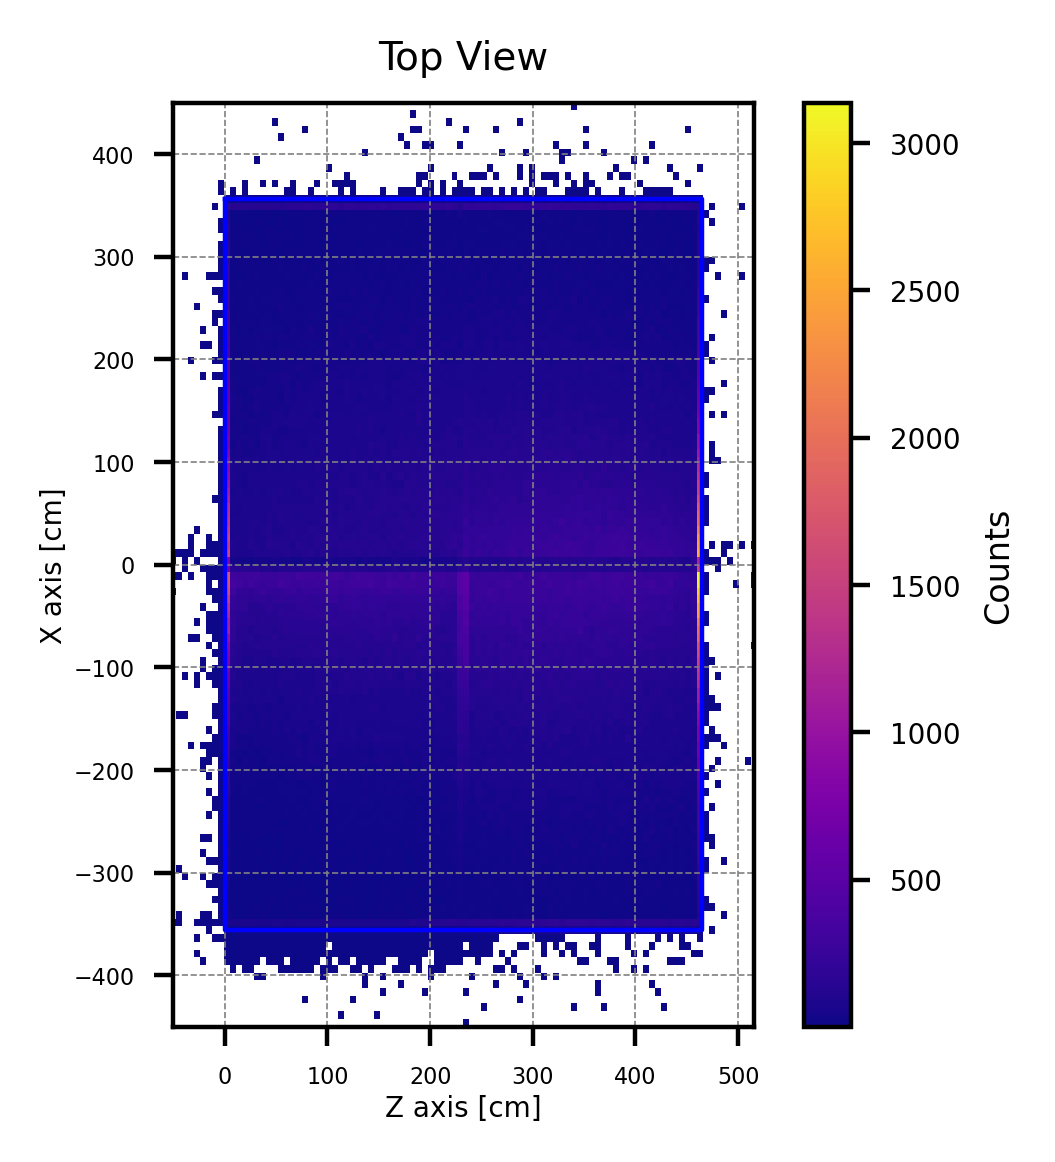

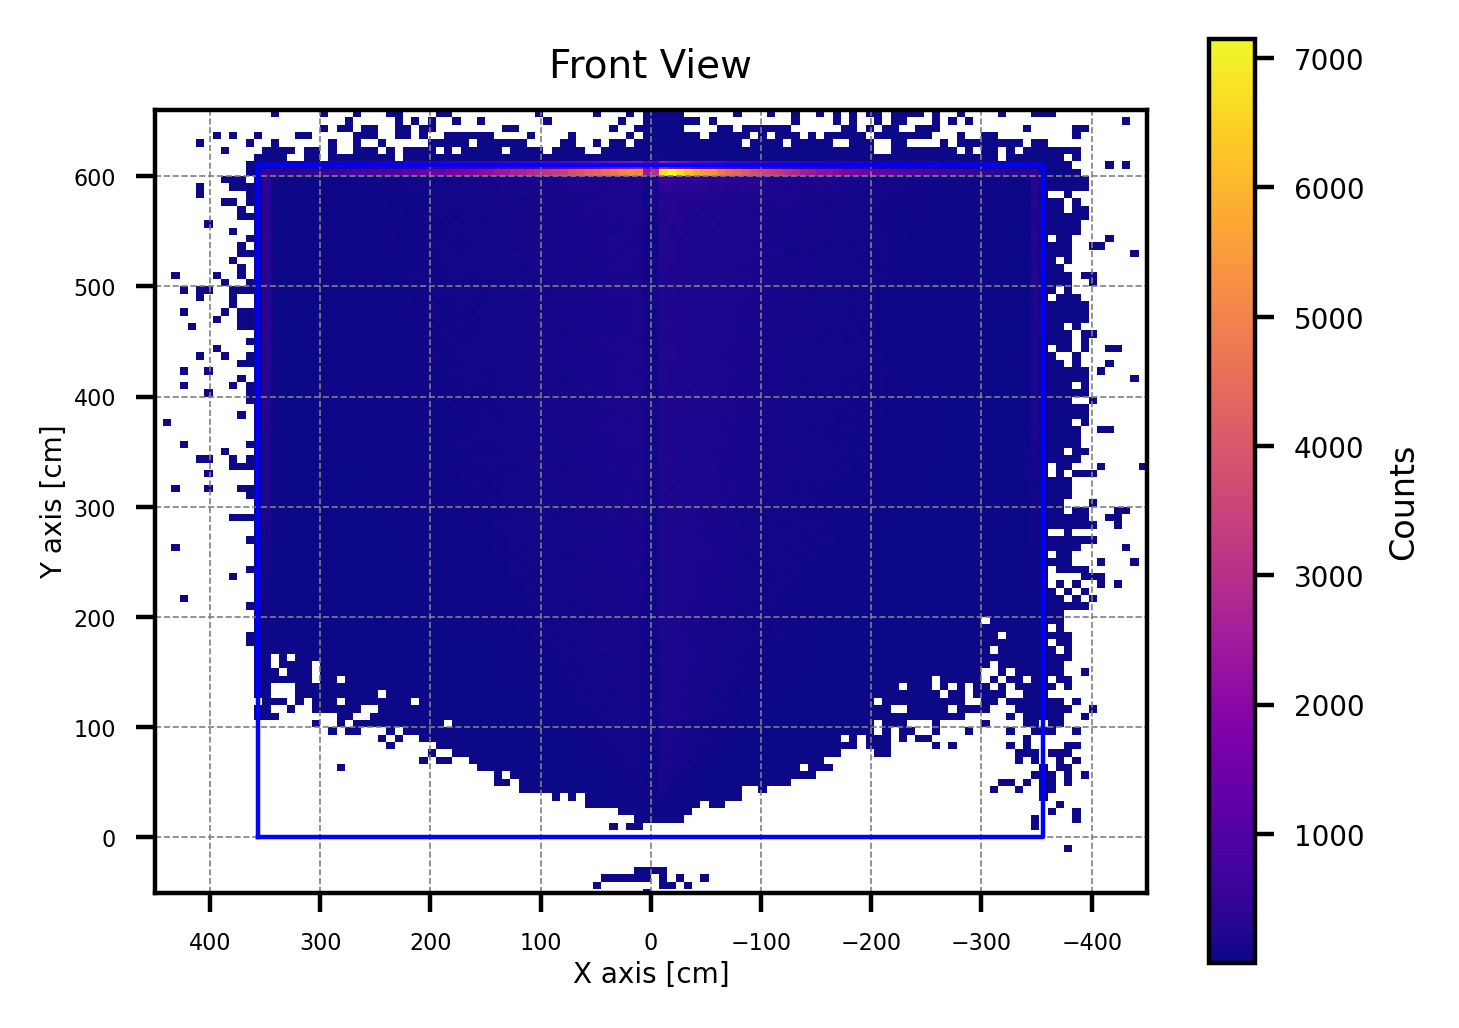

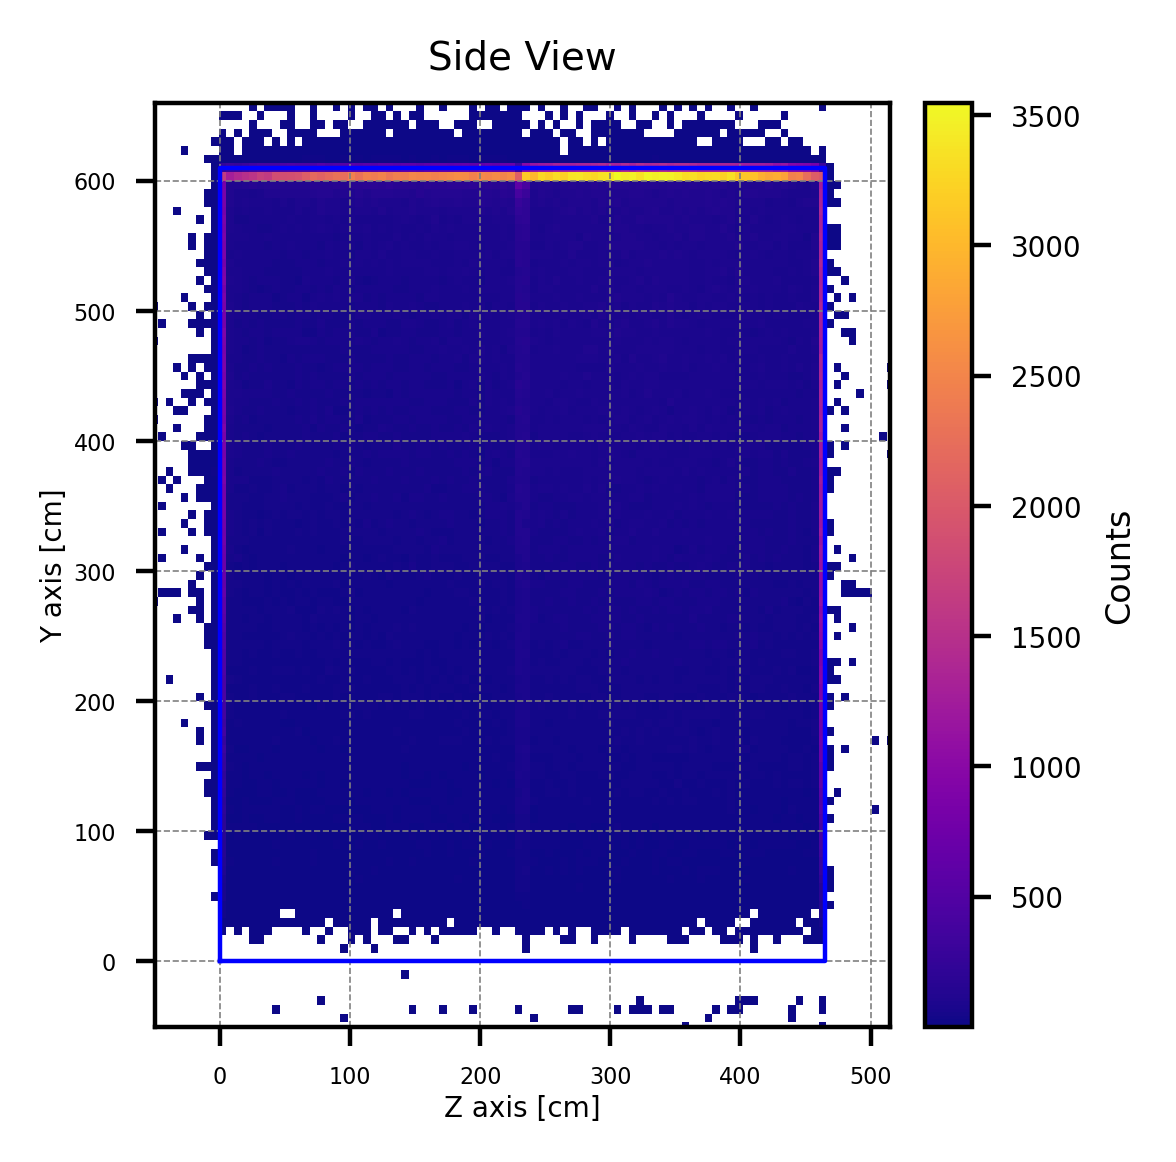

In [3]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startX_initial, vals_startY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [6]:
initial_MS_reco = []#To be consistent with data---
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---

initial_MS_true = []
Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

    if 0.0 <= MS:
        initial_MS_reco.append(ev)
        if E > 0:
            initial_MS_true.append(ev)

        #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
        if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
            Space_events_reco.append(ev)
            if E > 0:
                Space_events_true.append(ev)

            if  MS < 0.01: #(Michel score cut)---
                MS_events_reco.append(ev)
                if E > 0:
                    MS_events_true.append(ev)
            
                if MH < 3: #Michel hits cut---                
                    MH_events_reco.append(ev)
                    if E > 0:
                        MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (0.0<=MS): ", len(initial_MS_reco))
print("True events (0.0<=MS): ", len(initial_MS_true), "({:.2f}%)".format(len(initial_MS_true)/len(initial_MS_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  759879
True events (initial):  16189 (2.13%)

Reco events (0.0<=MS):  759879
True events (0.0<=MS):  16189 (2.13%)

Reco events (Space cut):  326352 (42.95%)
True events (Space cut):  13298 (4.07%)

Reco events (Space & MS cuts):  306798 (40.37%)
True events (Space & MS cuts):  12725 (4.15%)

Reco events (Space & MS & MH cuts):  306798 (40.37%)
True events (Space & MS & MH cuts):  12725 (4.15%)



### Apply all cuts:

In [ ]:

TPC_events_reco = [] # After Space & MS & MH cuts---

TPC_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if MS: #(Michel score cut)---
            
            if 3 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)
                if E > 0:
                    TPC_events_true.append(ev) 



print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(TPC_events_true), 
      "({:.2f}%)".format(len(TPC_events_true)/len(TPC_events_reco)*100))





Reco events (Space & MS & MH cuts):  0 (0.00%)


ZeroDivisionError: division by zero

Decay points distribution (After TPC cut): 
# of X < 0 :  49820 (39.797%)
# of X >= 0:  75365 (60.203%)

#decayX_TPC (total):  125185
#decayX_apa1:  3516 (2.81%)
#decayX_apa2:  46304 (36.99%)
#decayX_apa3:  32186 (25.71%)
#decayX_apa4:  43179 (34.49%)


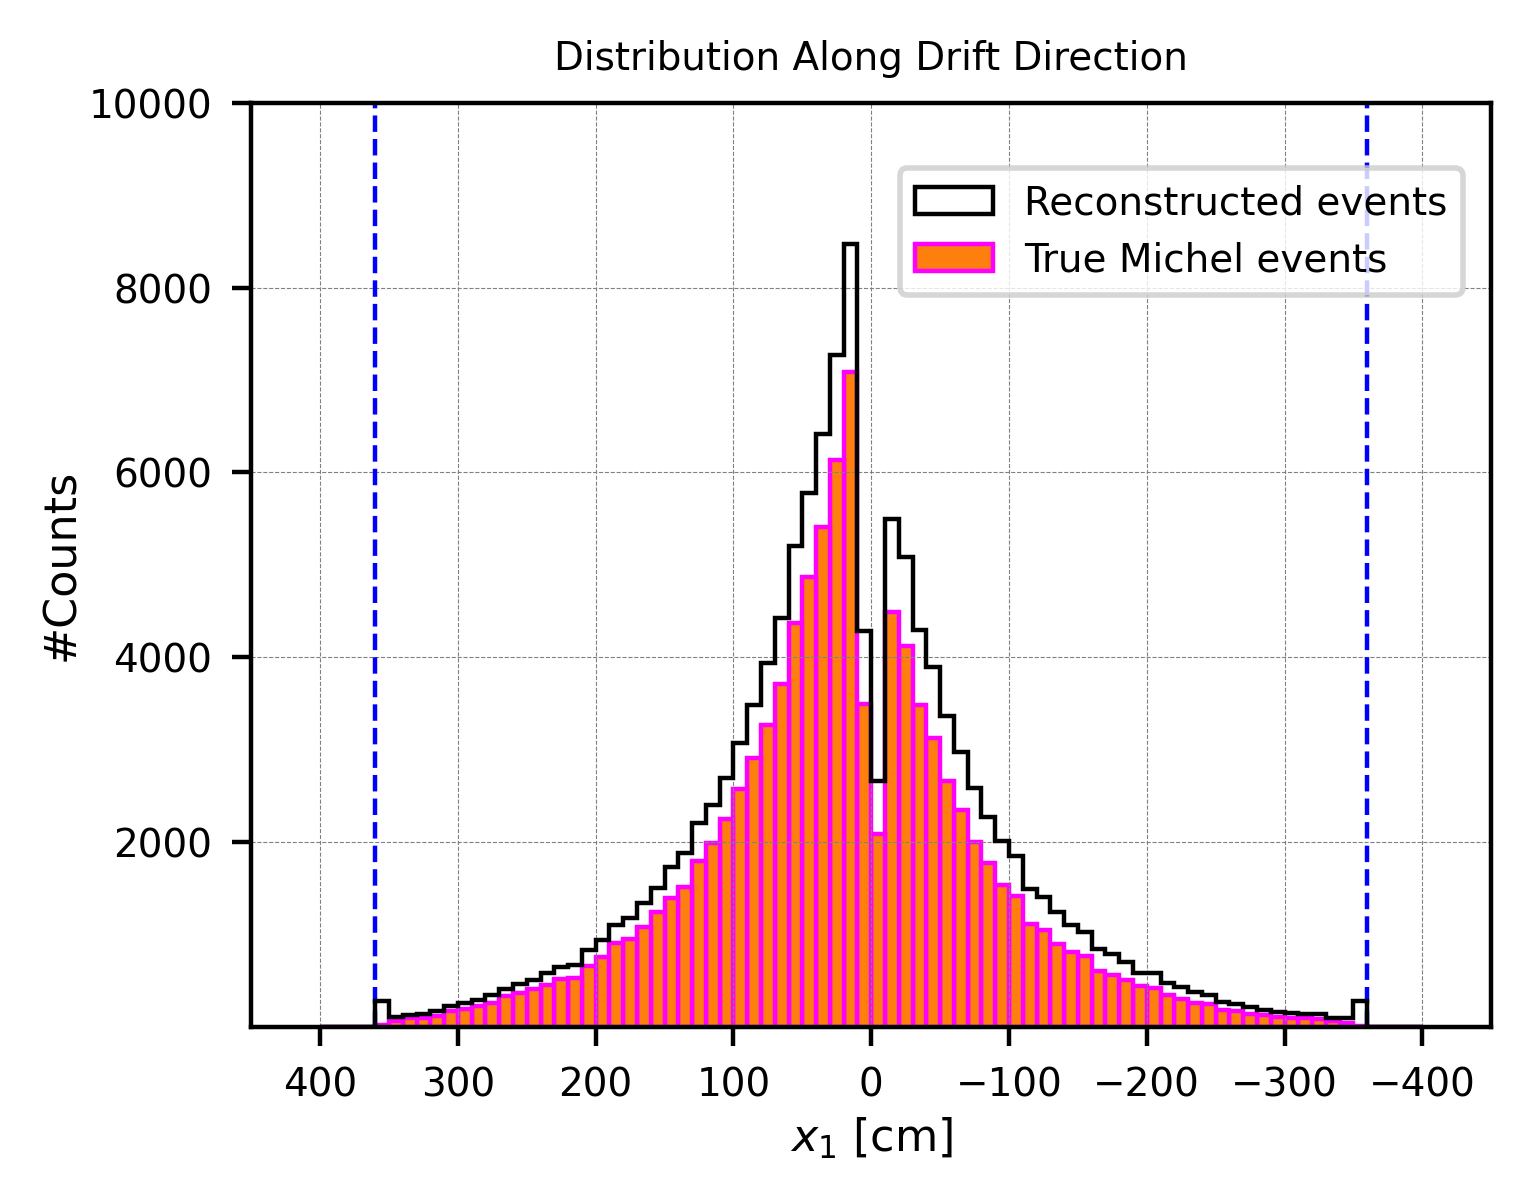

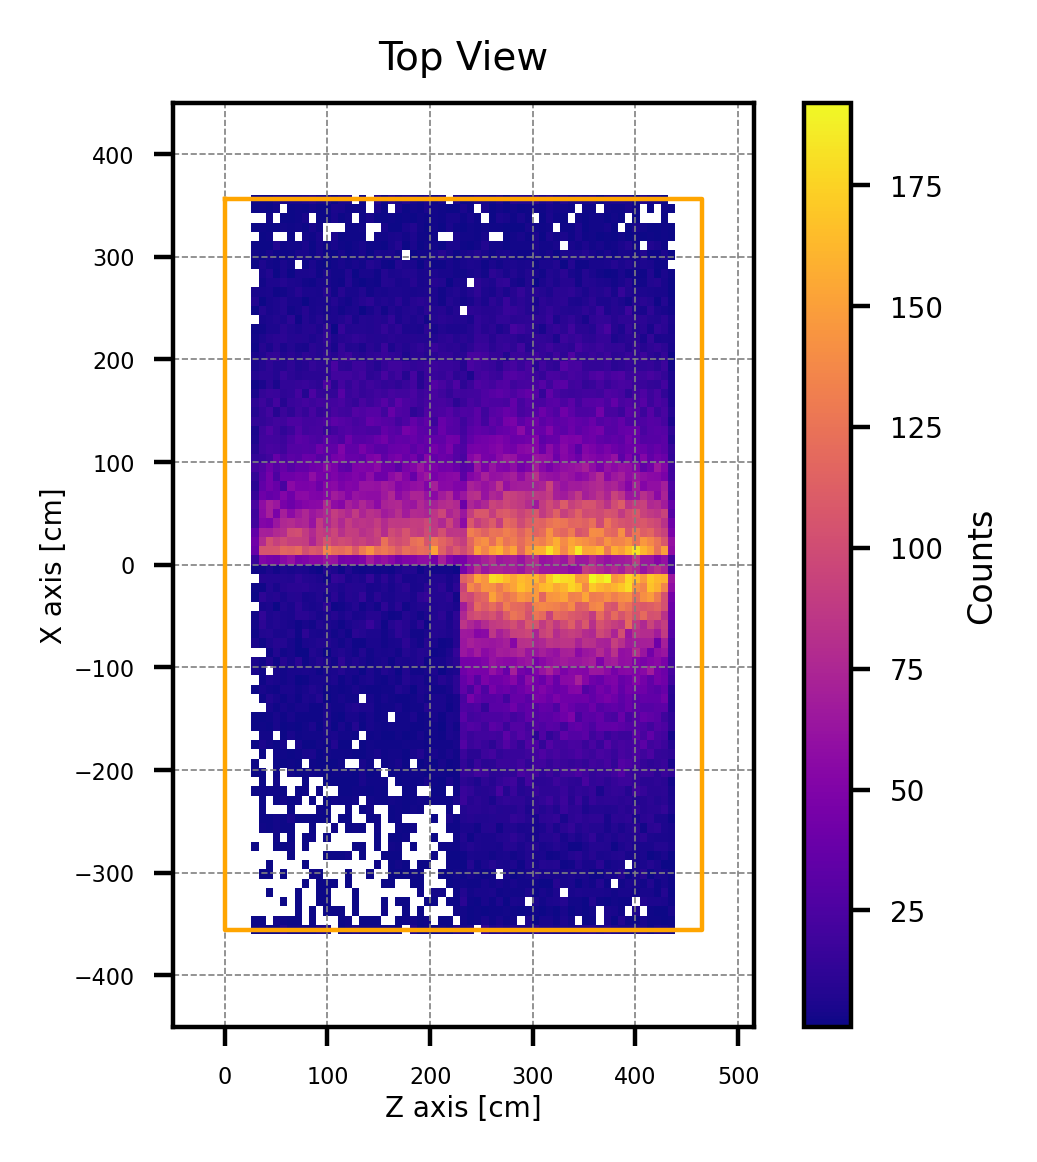

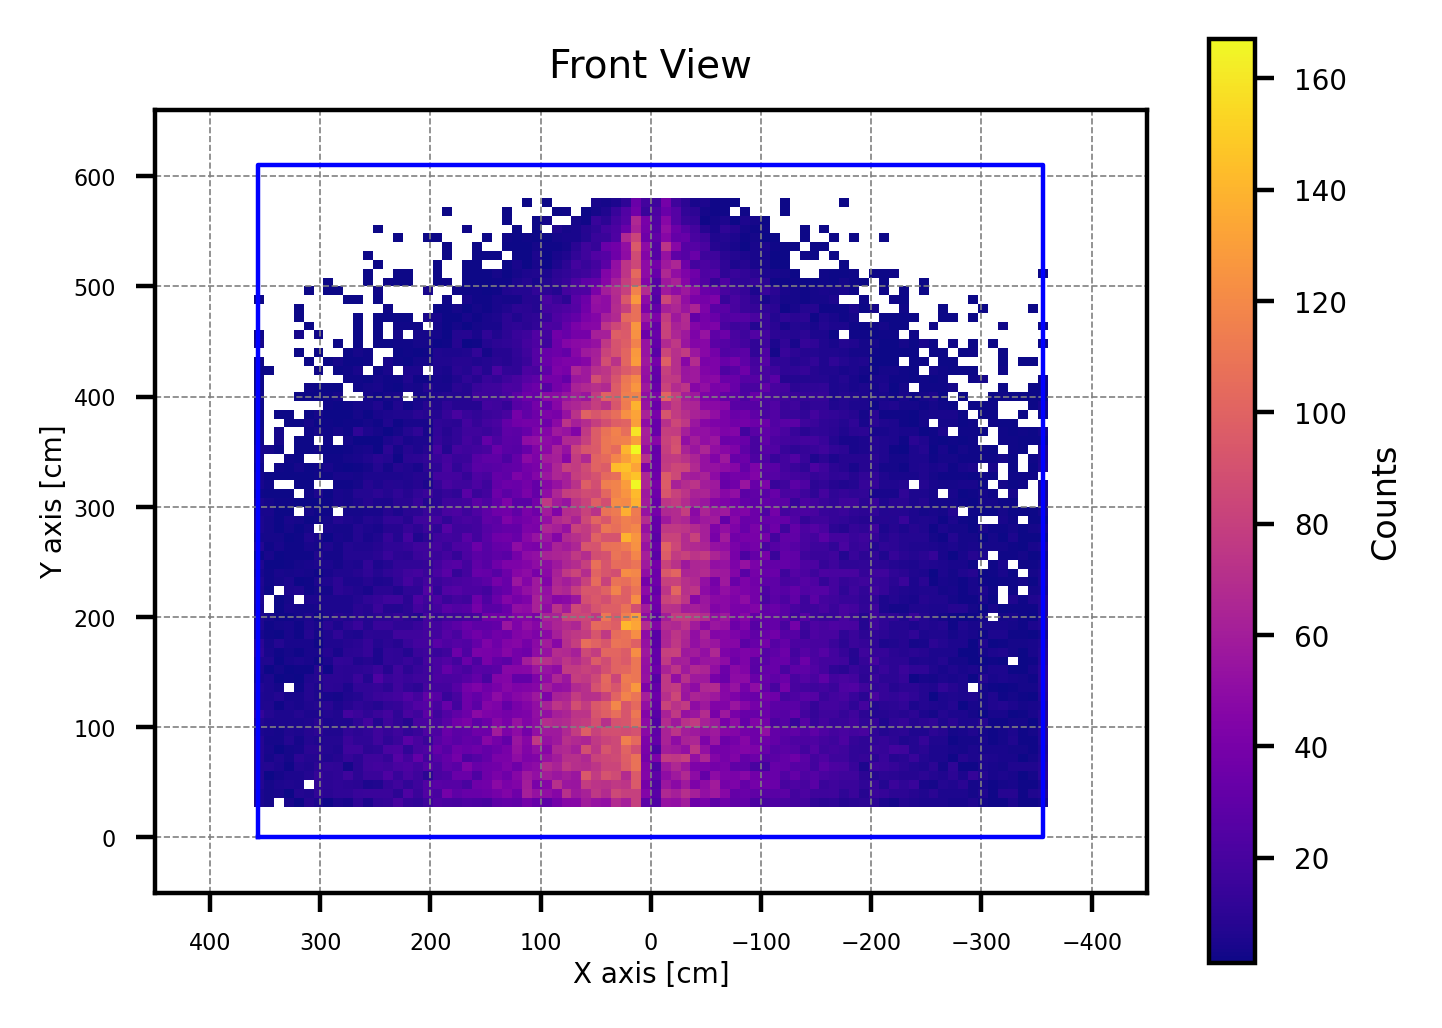

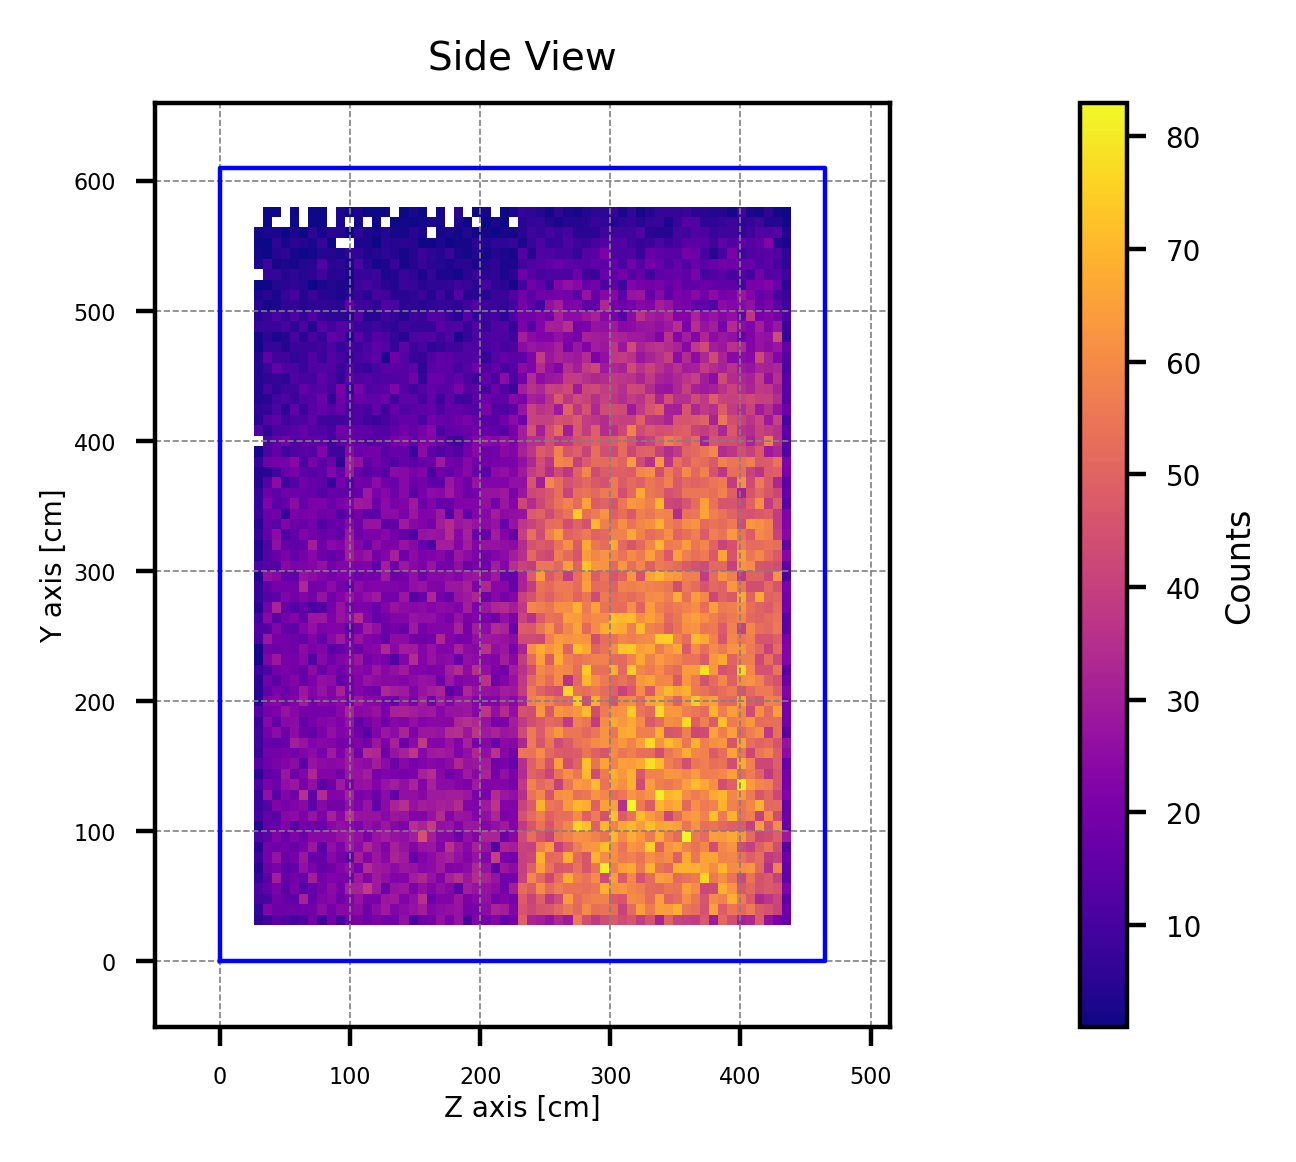

<Figure size 1600x1200 with 0 Axes>

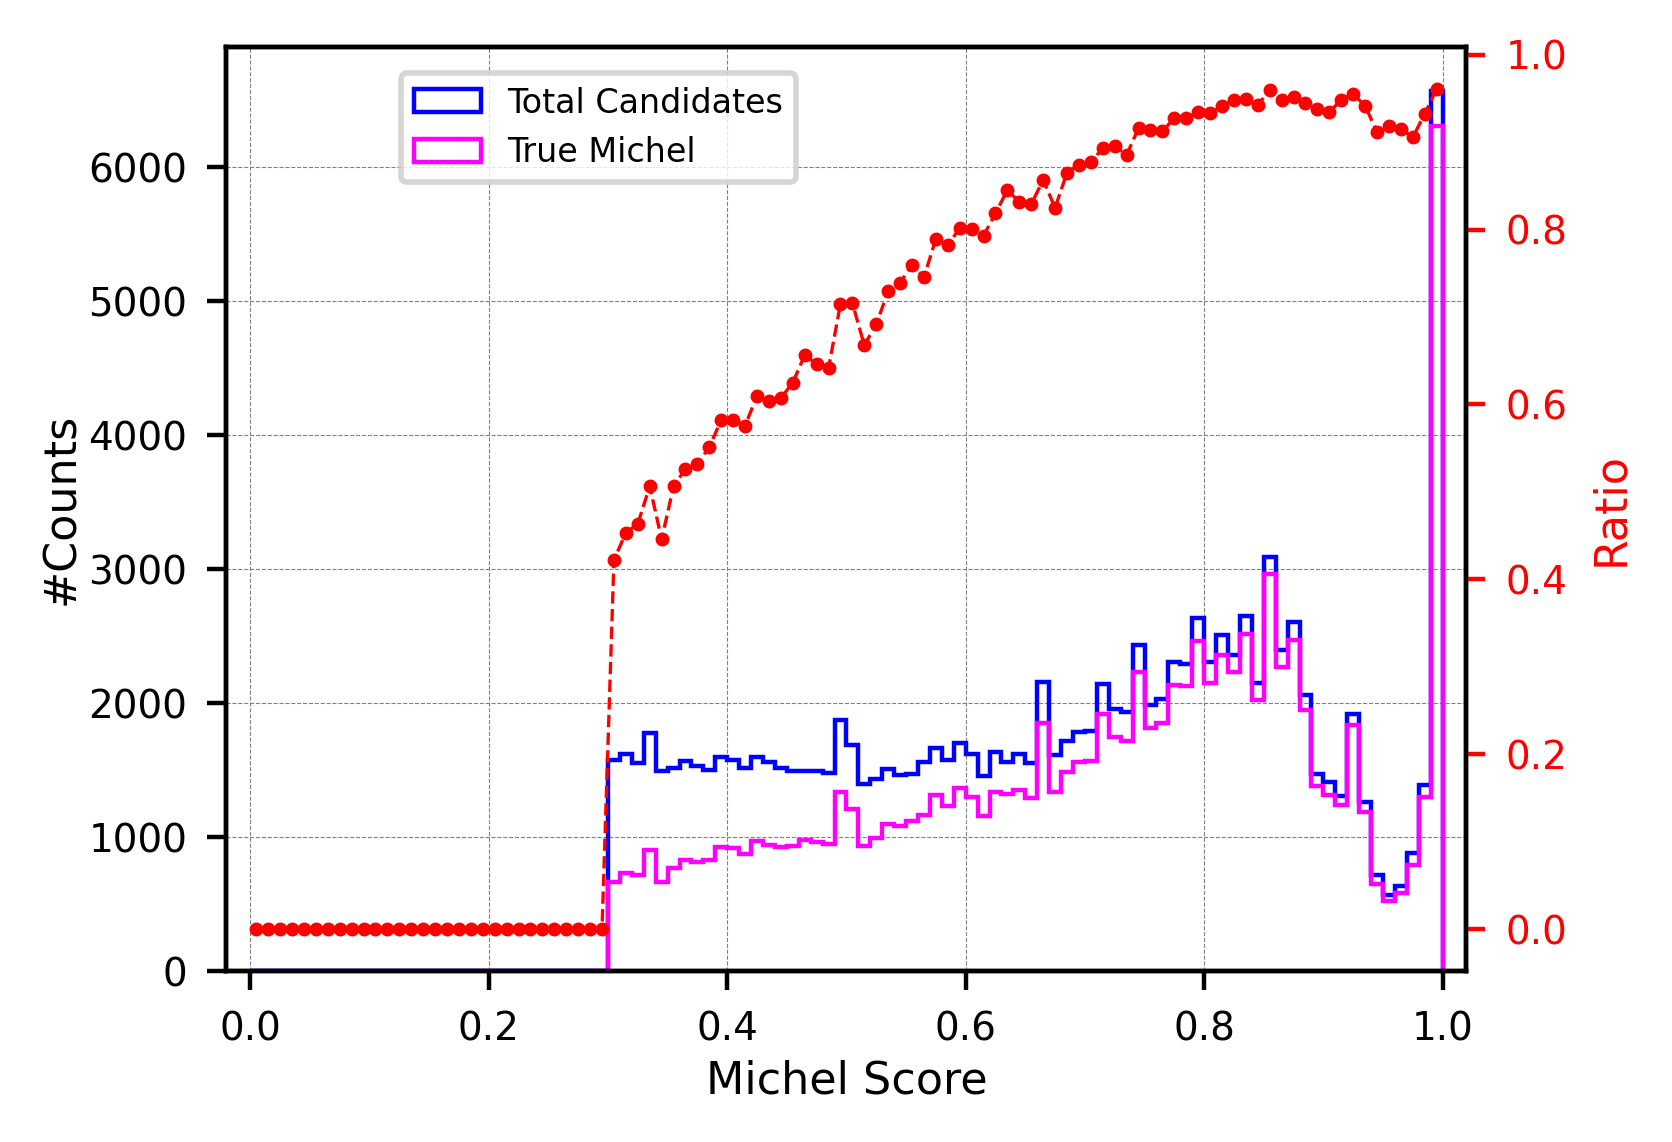

<Figure size 1600x1200 with 0 Axes>

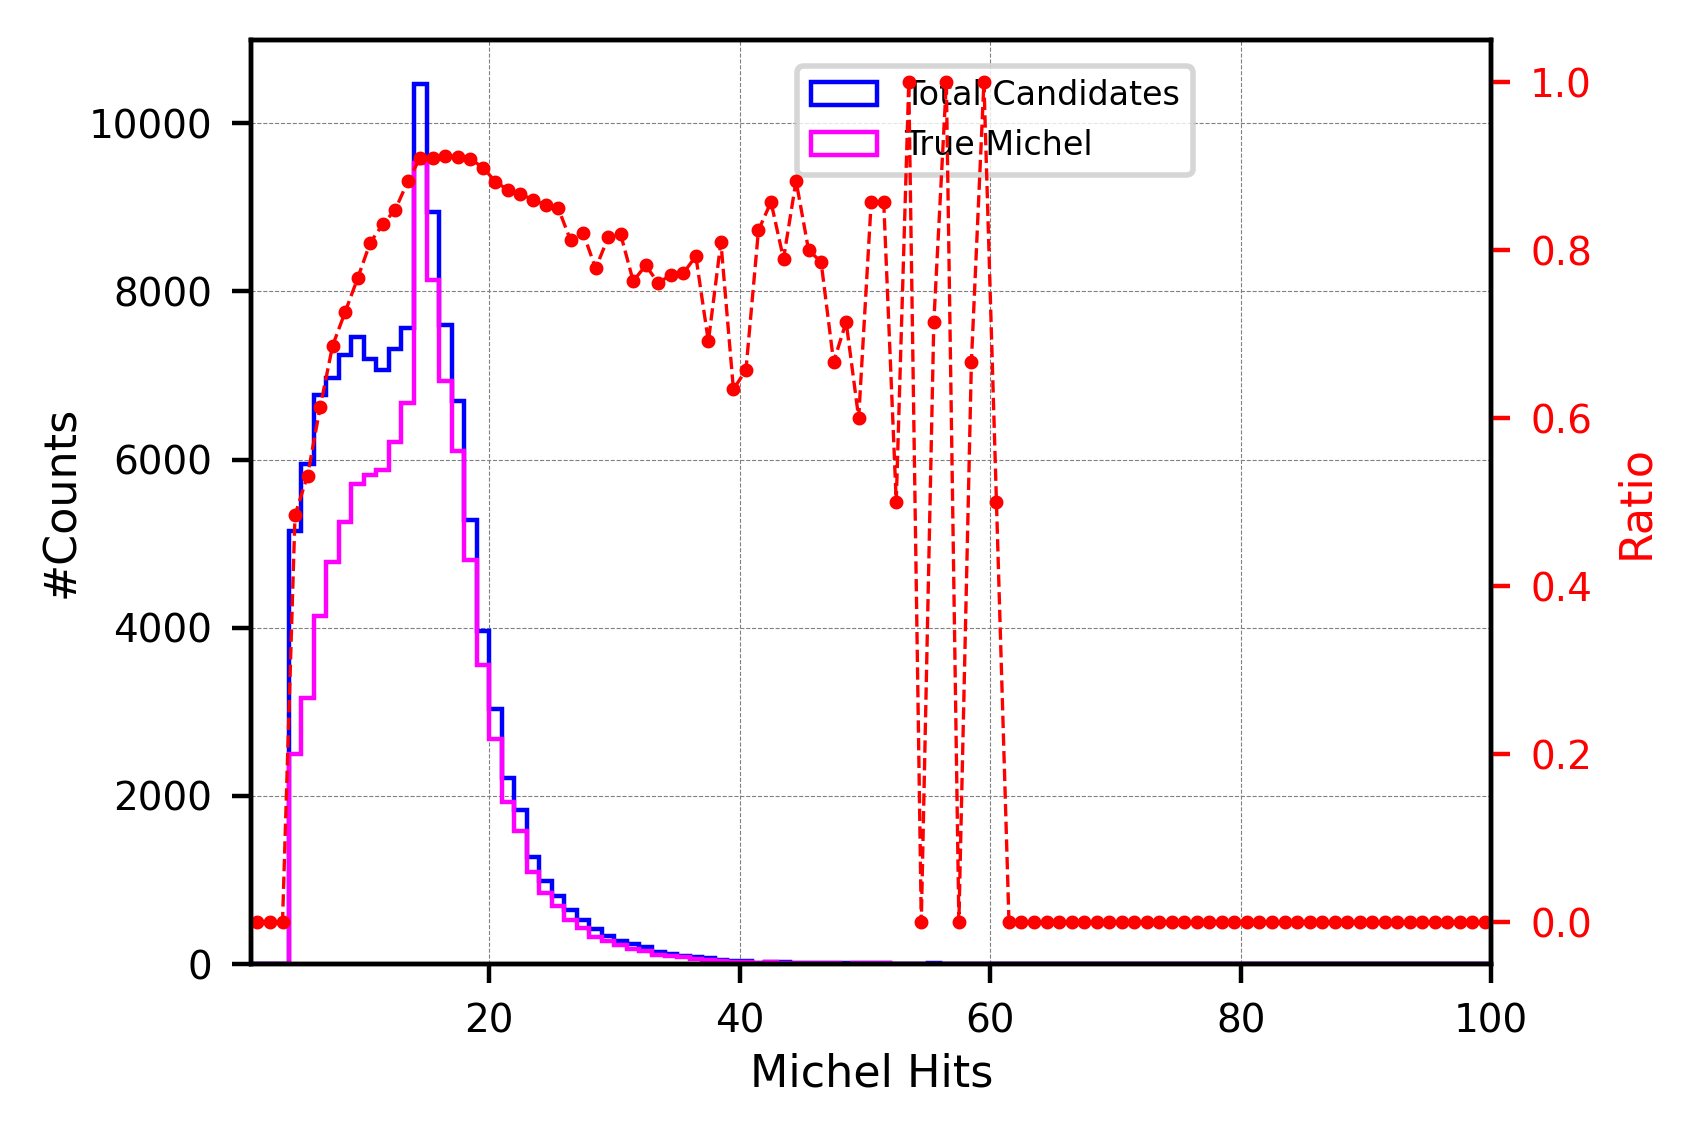




Starting points distribution: 


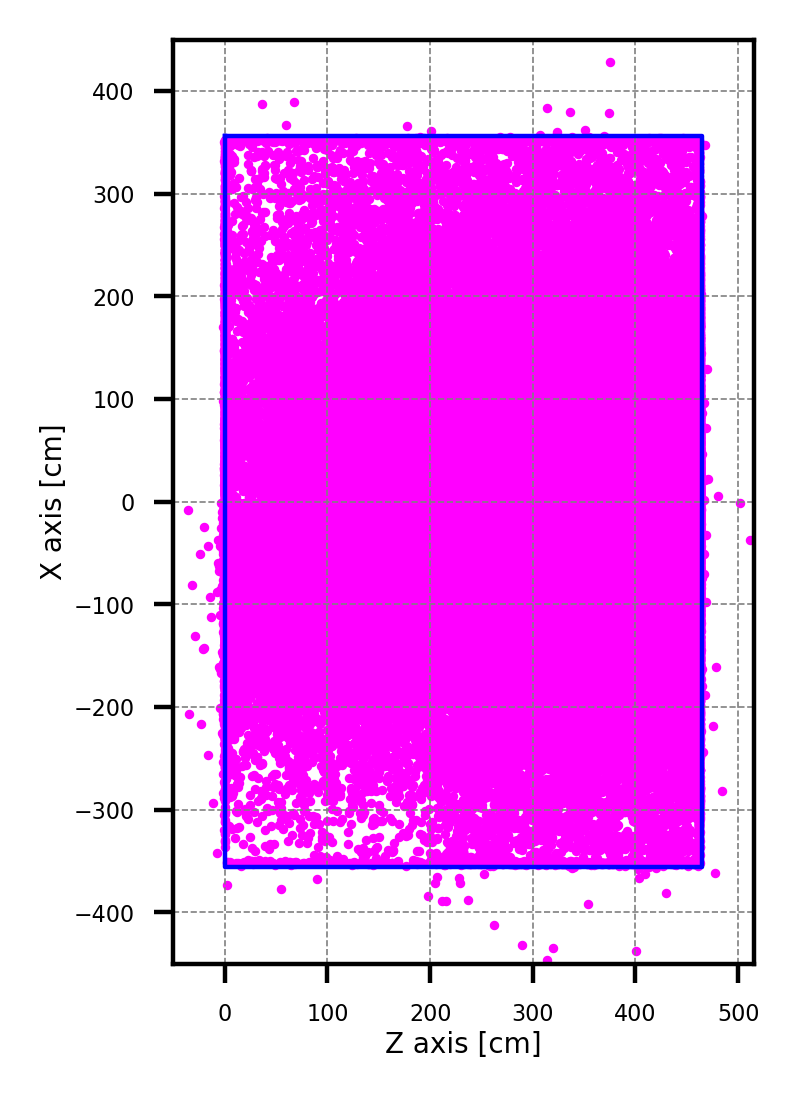

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



#### Remove Events in APA1:

In [ ]:
decayX_apa234 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        continue             
    else:
        decayX_apa234.append(x)

print("#decayX_apa234: ", len(decayX_apa234), "/", len(TPC_X),
      "({:.2f}%)".format(len(decayX_apa234)/len(TPC_X)*100))

np.save("decayX_apa234_MC.npy", decayX_apa234)

#decayX_apa234:  121669 / 125185 (97.19%)


### Energy & Lifetime distributions:

In [ ]:


# Seperate Michel e^- and e^+------------------------------
events_pM_TPC = []#e^+ events---
events_nM_TPC = []

for i in range(0, len(TPC_events_true)):
    pdg = TPC_events_true[i].pdg_initial

    if pdg < 0:
        events_pM_TPC.append(TPC_events_true[i])

    elif pdg > 0:
        events_nM_TPC.append(TPC_events_true[i])



print("Initial (before TPC cuts):")
print("Michel e^+: ", len(life_pM), "/", len(events_true), "({:.2f}%)".format(len(life_pM)/len(events_true)*100))
print("Michel e^-: ", len(life_nM), "/", len(events_true), "({:.2f}%)".format(len(life_nM)/len(events_true)*100))

print("#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))


print("\n\nAfter TPC cuts:")
print("Michel e^+: ", len(events_pM_TPC), "/", len(TPC_events_true), 
      "({:.2f}%)".format(len(events_pM_TPC)/len(TPC_events_true)*100))
print("Michel e^-: ", len(events_nM_TPC), "/", len(TPC_events_true), 
      "({:.2f}%)".format(len(events_nM_TPC)/len(TPC_events_true)*100))

print("#e^+ / #e^-: ", len(events_pM_TPC), "/", len(events_nM_TPC), 
      "({:.2f})".format(len(events_pM_TPC)/len(events_nM_TPC)))







Initial (before TPC cuts):
Michel e^+:  123889 / 150372 (82.39%)
Michel e^-:  26483 / 150372 (17.61%)
#e^+ / #e^-:  123889 / 26483 (4.68)


After TPC cuts:
Michel e^+:  82836 / 100678 (82.28%)
Michel e^-:  17842 / 100678 (17.72%)
#e^+ / #e^-:  82836 / 17842 (4.64)


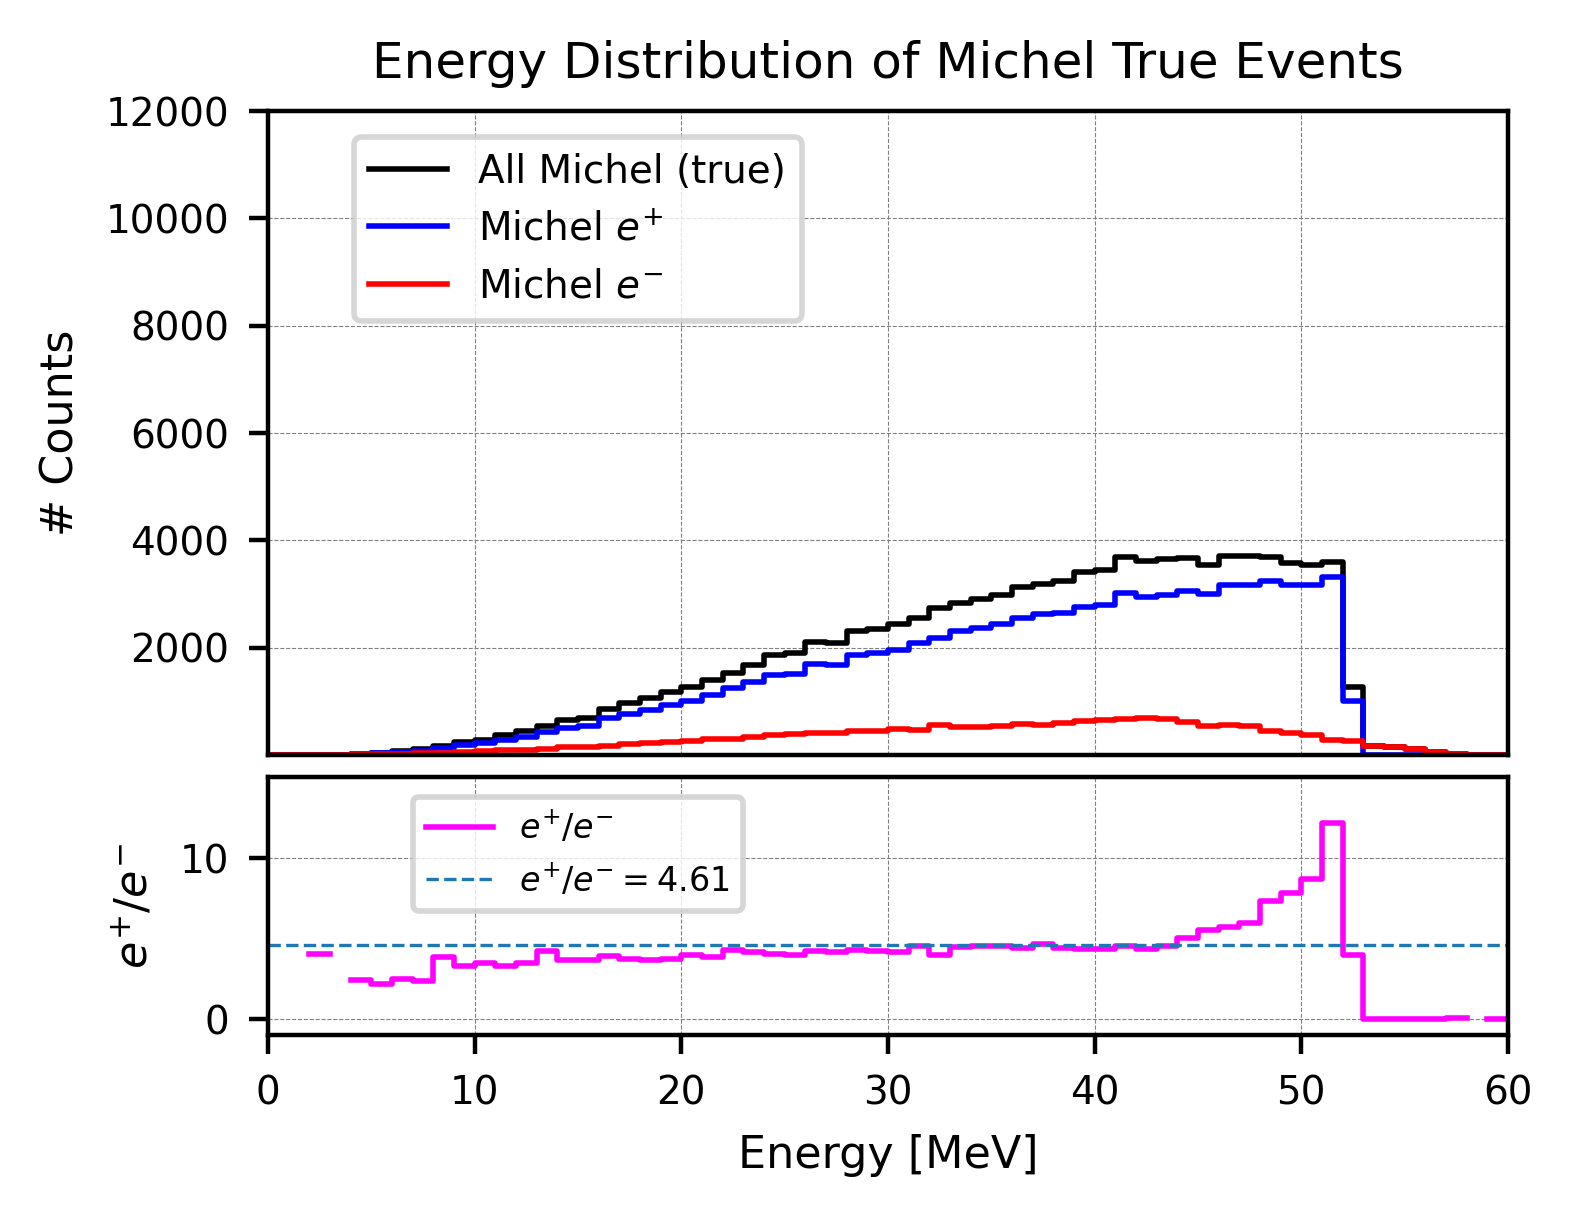

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# -------------------------------------------------
# Prepare energy arrays
# -------------------------------------------------
vals_energy_total = np.array([ev.energy_initial for ev in TPC_events_true])
vals_energy_pM    = np.array([ev.energy_initial for ev in events_pM_TPC])
vals_energy_nM    = np.array([ev.energy_initial for ev in events_nM_TPC])

# -------------------------------------------------
# Binning
# -------------------------------------------------
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# Counts (explicit)
h_tot, _ = np.histogram(vals_energy_total, bins=bins)
h_pM,  _ = np.histogram(vals_energy_pM,    bins=bins)
h_nM,  _ = np.histogram(vals_energy_nM,    bins=bins)

# Ratio: e+ / e- (skip bins where e- == 0)
ratio = np.full(nb, np.nan, dtype=float)
mask = h_nM > 0
ratio[mask] = h_pM[mask] / h_nM[mask]

# -------------------------------------------------
# Figure: GridSpec two panels (like your lifetime script)
# -------------------------------------------------
fig = plt.figure(figsize=(4, 3), dpi=400)
gs = GridSpec(2, 1, height_ratios=[5, 2], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# -------------------------------------------------
# Top panel: step histograms (use step() so it matches bins exactly)
# -------------------------------------------------
ax_top.step(bins[:-1], h_tot, where='post', color='black', linewidth=1.0, label='All Michel (true)')
ax_top.step(bins[:-1], h_pM,  where='post', color='blue', linewidth=1.0, label='Michel $e^{+}$')
ax_top.step(bins[:-1], h_nM,  where='post', color='red', linewidth=1.0, label='Michel $e^{-}$')

ax_top.set_xlim(0, 60)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_ylim(0.9, 12000)
#ax_top.set_yscale('log')
ax_top.set_ylabel('# Counts', fontsize=8)
ax_top.tick_params(labelsize=7)
ax_top.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})
ax_top.set_title('Energy Distribution of Michel True Events', fontsize=9)



# -------------------------------------------------
# Bottom panel: ratio (step-mid to match histogram bins)
# -------------------------------------------------
ax_bot.plot(bin_centers, ratio, drawstyle='steps-mid', color='magenta', linewidth=1.0, label='$e^{+}/e^{-}$')
ax_bot.axhline(4.61, linestyle='--', linewidth=0.6, label='$e^{+}/e^{-} = 4.61$')

ax_bot.set_xlim(0, 60)
ax_bot.set_ylim(-1, 15)
ax_bot.set_xlabel('Energy [MeV]', fontsize=8)
ax_bot.set_ylabel('$e^{+}/e^{-}$', fontsize=8)
ax_bot.tick_params(labelsize=7)

ax_bot.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_bot.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=6, markerscale=4, ncol=1, prop={'size':6})


plt.show()


### New fittings:


========== e⁺ Minuit fit summary ==========
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 98.66 (χ²/ndof = 1.0)      │              Nfcn = 43               │
│ EDM = 3.22e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

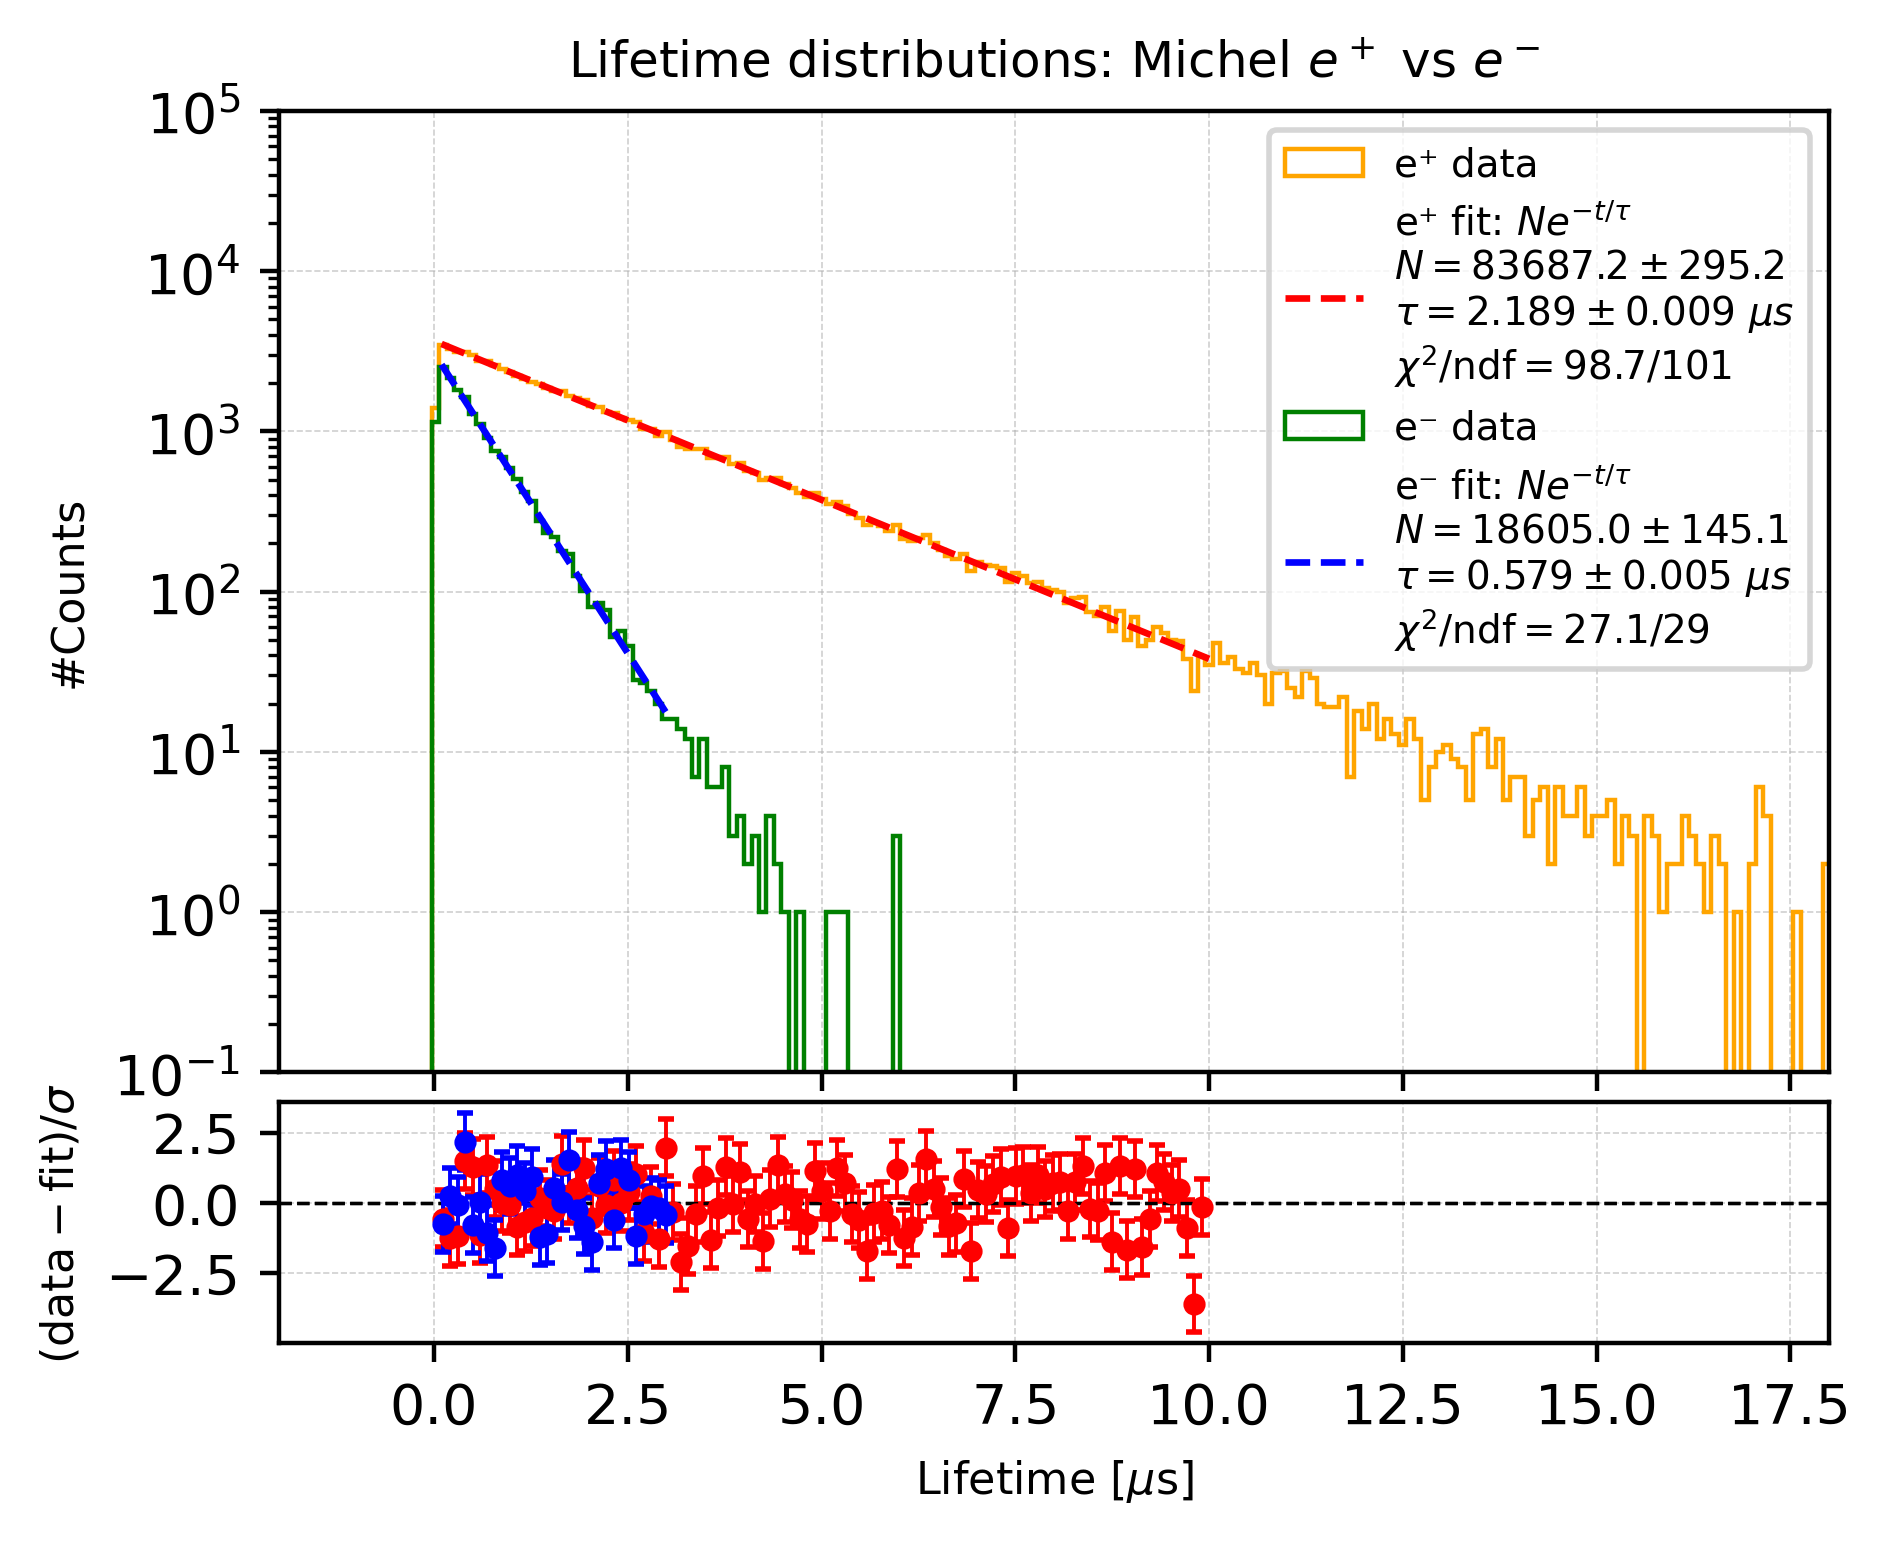

In [ ]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt



TPC_lifetime_pM = [ev.lifetime_initial for ev in events_pM_TPC]
TPC_lifetime_nM = [ev.lifetime_initial for ev in events_nM_TPC]



# ==========================================================
# Configuration
# ==========================================================
bin_width = 0.096
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)


# ==========================================================
# Bin-integrated model
# ==========================================================
def exp1_integrated(bin_edges, N, tau):
    """
    Expected counts per bin for exponential decay model.

    Model:
        f(t) = (N / tau) * exp(-t / tau)

    Bin expectation in [a, b]:
        mu(a, b) = N * (exp(-a / tau) - exp(-b / tau))

    Parameters
    ----------
    bin_edges : array
        Array of bin edges, length = n_bins + 1
    N : float
        Total normalization
    tau : float
        Lifetime in us

    Returns
    -------
    array
        Expected counts in each bin
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


def exp1_integrated_from_leftedge(x_left, N, tau):
    """
    Wrapper for LeastSquares.

    Here x_left is the LEFT edge of each selected bin.
    Since each bin has width = bin_width, the expected count is

        mu = N * (exp(-a/tau) - exp(-(a + bin_width)/tau))
    """
    a = np.asarray(x_left)
    b = a + bin_width
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


# ==========================================================
# Minuit fitting helper
# ==========================================================
def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # -----------------------------
    # Histogram
    # -----------------------------
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Full histogram draw
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # -----------------------------
    # Fit window
    # -----------------------------
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])

    if np.count_nonzero(m) < 3:
        return None

    x_center = centers[m]
    y = counts[m]

    # Convert chosen bins to left edges
    x_left = x_center - 0.5 * bin_width

    # Poisson-like display uncertainty, same as your old script
    sigma = np.sqrt(np.maximum(y, 1.0))

    # -----------------------------
    # Least-squares cost for Minuit
    # -----------------------------
    lsq = LeastSquares(x_left, y, sigma, exp1_integrated_from_leftedge)

    # Initial values
    N0 = np.sum(y)
    tau0 = 2.0

    mfit = Minuit(lsq, N=N0, tau=tau0)

    # Parameter limits
    mfit.limits["N"] = (0.0, None)
    mfit.limits["tau"] = (1e-6, None)

    # Optional stability settings
    mfit.errordef = Minuit.LEAST_SQUARES

    # Minimize
    mfit.migrad()
    mfit.hesse()

    # If needed later:
    # mfit.minos("tau")

    if not mfit.valid:
        print(f"[WARNING] Fit for {label_prefix} is not fully valid.")

    # -----------------------------
    # Fit results
    # -----------------------------
    N_fit = mfit.values["N"]
    tau_fit = mfit.values["tau"]

    N_err = mfit.errors["N"]
    tau_err = mfit.errors["tau"]

    # Model values at fitted bins
    y_model = exp1_integrated_from_leftedge(x_left, N_fit, tau_fit)

    # Pulls
    pulls = (y - y_model) / sigma

    # Chi2 / ndf
    chi2 = mfit.fval
    ndf = len(y) - mfit.nfit

    # -----------------------------
    # Smooth curve for visualization
    # -----------------------------
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau_fit) * np.exp(-x_smooth / tau_fit) * bin_width

    # -----------------------------
    # Draw fit curve
    # -----------------------------
    ax.plot(
        x_smooth, y_smooth,
        color=fit_color, linestyle="--", linewidth=1.2,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    # -----------------------------
    # Residuals / pulls
    # -----------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        x_center, pulls, yerr=np.ones_like(pulls), fmt='o',
        color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # -----------------------------
    # Print summary
    # -----------------------------
    print("")
    print(f"========== {label_prefix} Minuit fit summary ==========")
    print(mfit)
    print("")
    print("Covariance matrix:")
    print(mfit.covariance)
    print("")

    return tau_fit, tau_err, chi2, ndf


# ==========================================================
# Plot with residual panel
# ==========================================================
fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+
fit_and_draw(
    ax, ax_resid,
    np.asarray(TPC_lifetime_pM),
    "e⁺",
    fit_range=(0.096, 10.0),
    hist_color="orange",
    fit_color="red"
)

# Fit e-
fit_and_draw(
    ax, ax_resid,
    np.asarray(TPC_lifetime_nM),
    "e⁻",
    fit_range=(0.096, 3.0),
    hist_color="green",
    fit_color="blue"
)

# ==========================================================
# Style top plot
# ==========================================================
ax.set_ylim(0.1, 100000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# ==========================================================
# Style residuals
# ==========================================================
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />

### Explore x-axis distribution asymmetry (20260615):

In [ ]:
#X-Z track drawing function==============================

def draw_tracks_xz(
    event_list,
    n_tracks=1000,
    figsize=(4, 3),
    dpi=400,
    track_lw=0.4,
    track_alpha=0.5
):
    """
    Draw reconstructed tracks in the X-Z plane.

    Parameters
    ----------
    event_list : list
        List of ParticleEvent objects.
    n_tracks : int
        Number of tracks to draw.
    figsize : tuple
        Figure size.
    dpi : int
        Figure DPI.
    track_lw : float
        Track line width.
    track_alpha : float
        Track transparency.
    """

    plt.figure(figsize=figsize, dpi=dpi)

    # TPC boundary
    aux1 = [0, 465, 465, 0, 0]      # Z coordinates
    aux2 = [356, 356, -356, -356, 356]  # X coordinates

    plt.plot(
        aux1,
        aux2,
        color="orange",
        linewidth=0.8,
        linestyle="-",
        label="TPC boundary"
    )

    for event in event_list[:n_tracks]:

        # Skip incomplete events
        if (
            event.startX_initial is None
            or event.startZ_initial is None
            or event.decayX_initial is None
            or event.decayZ_initial is None
        ):
            continue

        x_values = [event.startX_initial, event.decayX_initial]
        z_values = [event.startZ_initial, event.decayZ_initial]

        plt.plot(
            z_values,
            x_values,
            linewidth=track_lw,
            alpha=track_alpha
        )

    plt.axis("scaled")
    plt.ylim(-450, 450)
    plt.xlim(-50, 515)

    plt.ylabel("X axis [cm]", labelpad=1, fontsize=5)
    plt.xlabel("Z axis [cm]", labelpad=1, fontsize=5)

    plt.tick_params(labelsize=4)
    plt.grid(color="gray",
        linestyle="--",
        linewidth=0.3,
        zorder=0
    )

    plt.tight_layout()
    plt.show()

In [ ]:
#Check if a track crosses line [x1, z1) = (0, 0) and (x2, z2)= (0, 231.3)]

def segments_intersect(p1, p2, q1, q2, eps=1e-9):
    """
    Check whether two 2D line segments p1-p2 and q1-q2 intersect.

    Points are given as (x, z).
    """

    def orientation(a, b, c):
        return (
            (b[1] - a[1]) * (c[0] - b[0])
            - (b[0] - a[0]) * (c[1] - b[1])
        )

    def on_segment(a, b, c):
        return (
            min(a[0], c[0]) - eps <= b[0] <= max(a[0], c[0]) + eps
            and
            min(a[1], c[1]) - eps <= b[1] <= max(a[1], c[1]) + eps
        )

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    # General intersection
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True

    # Collinear / endpoint-touching cases
    if abs(o1) < eps and on_segment(p1, q1, p2):
        return True
    if abs(o2) < eps and on_segment(p1, q2, p2):
        return True
    if abs(o3) < eps and on_segment(q1, p1, q2):
        return True
    if abs(o4) < eps and on_segment(q1, p2, q2):
        return True

    return False




def split_tracks_by_APA1_boundaries(
    event_list,
    x1=0.0,
    z1=0.0,
    x2=0.0,
    z2=231.3,
    x3=-356.0,
    z3=0.0,
    x4=-356.0,
    z4=231.3
):
    """
    Split tracks according to whether they cross either APA1 boundary segment.

    Segment 1:
        (x1, z1) -> (x2, z2)

    Segment 2:
        (x3, z3) -> (x4, z4)

    If a track crosses either segment, it is saved to TPC_events_reco_APA1.
    Otherwise, it is saved to TPC_events_reco_NoAPA1.
    """

    TPC_events_reco_APA1 = []
    TPC_events_reco_NoAPA1 = []

    boundary_1_p1 = (x1, z1)
    boundary_1_p2 = (x2, z2)

    boundary_2_p1 = (x3, z3)
    boundary_2_p2 = (x4, z4)

    for event in event_list:

        if (
            event.startX_initial is None or
            event.startZ_initial is None or
            event.decayX_initial is None or
            event.decayZ_initial is None
        ):
            continue

        track_p1 = (event.startX_initial, event.startZ_initial)
        track_p2 = (event.decayX_initial, event.decayZ_initial)

        crosses_boundary_1 = segments_intersect(
            track_p1,
            track_p2,
            boundary_1_p1,
            boundary_1_p2
        )

        crosses_boundary_2 = segments_intersect(
            track_p1,
            track_p2,
            boundary_2_p1,
            boundary_2_p2
        )

        if crosses_boundary_1 or crosses_boundary_2:
            TPC_events_reco_APA1.append(event)
        else:
            TPC_events_reco_NoAPA1.append(event)

    return TPC_events_reco_NoAPA1, TPC_events_reco_APA1




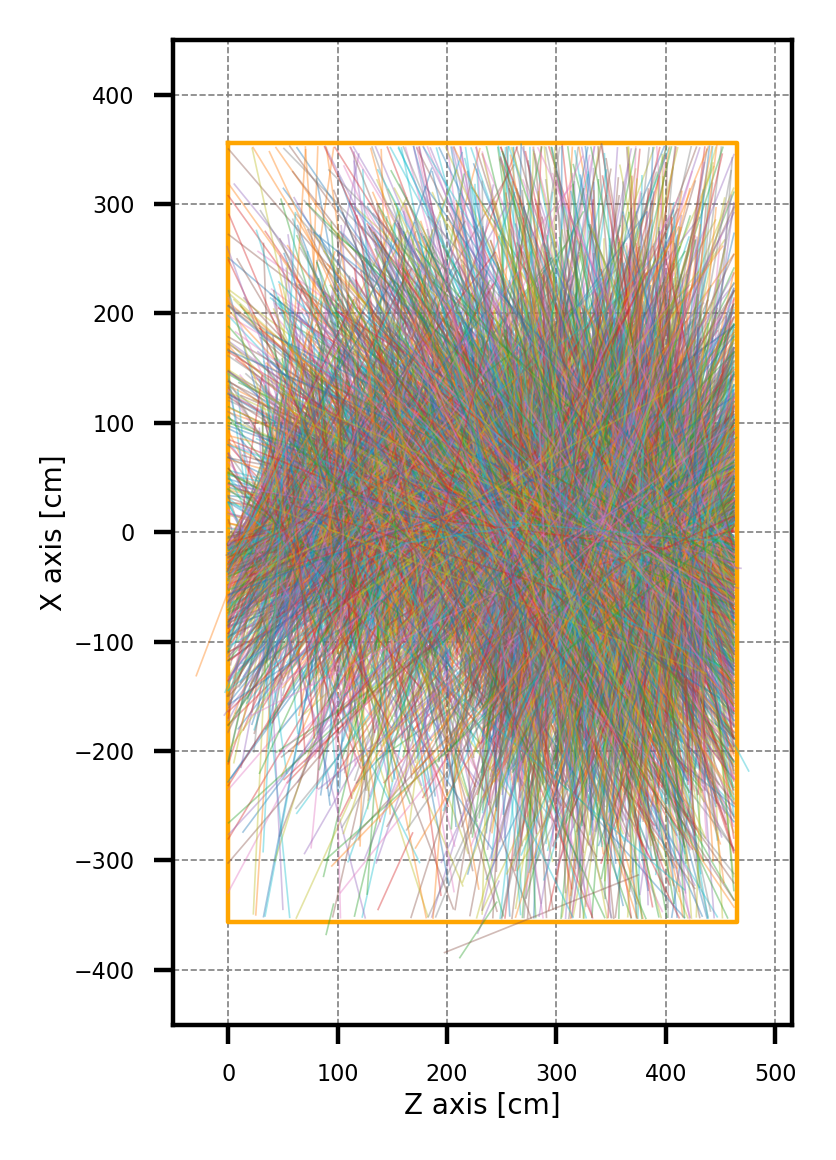

TPC_events_reco :  125185
No APA1 crossing:  89082 (71.16%)
APA1 crossing   :  36103 (28.84%)


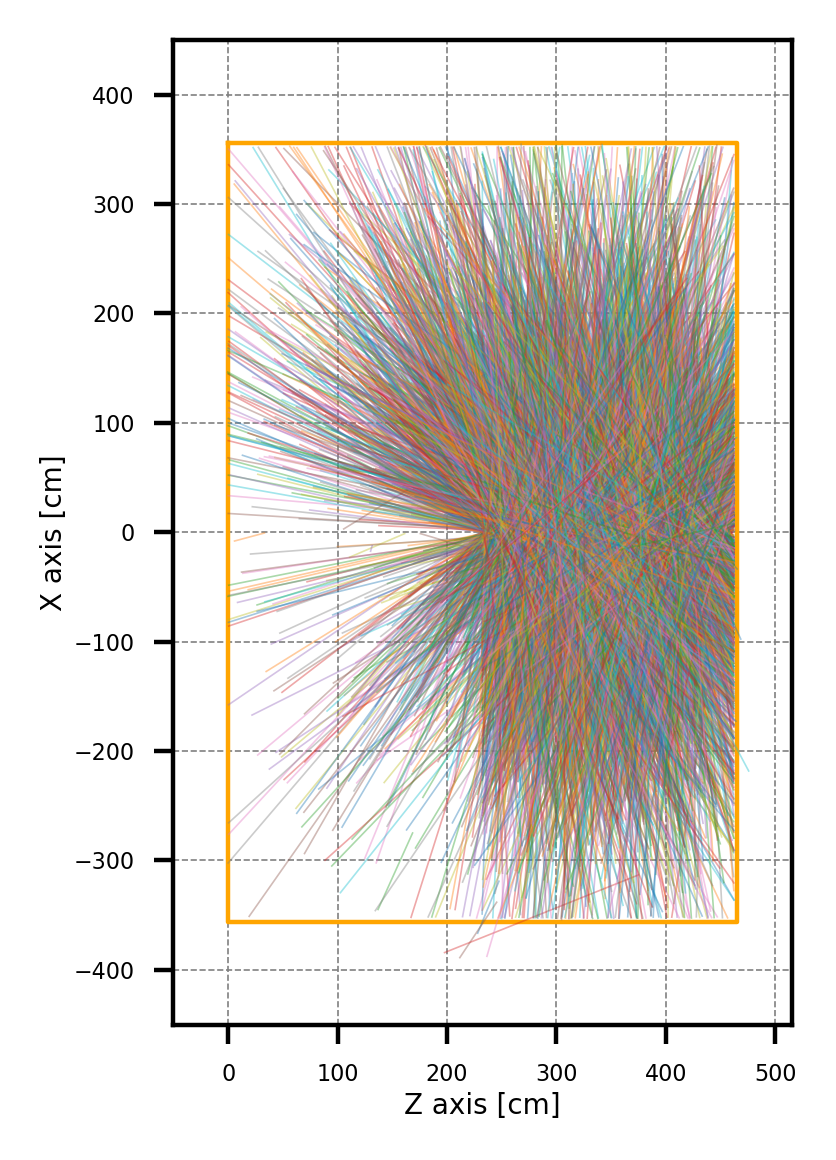

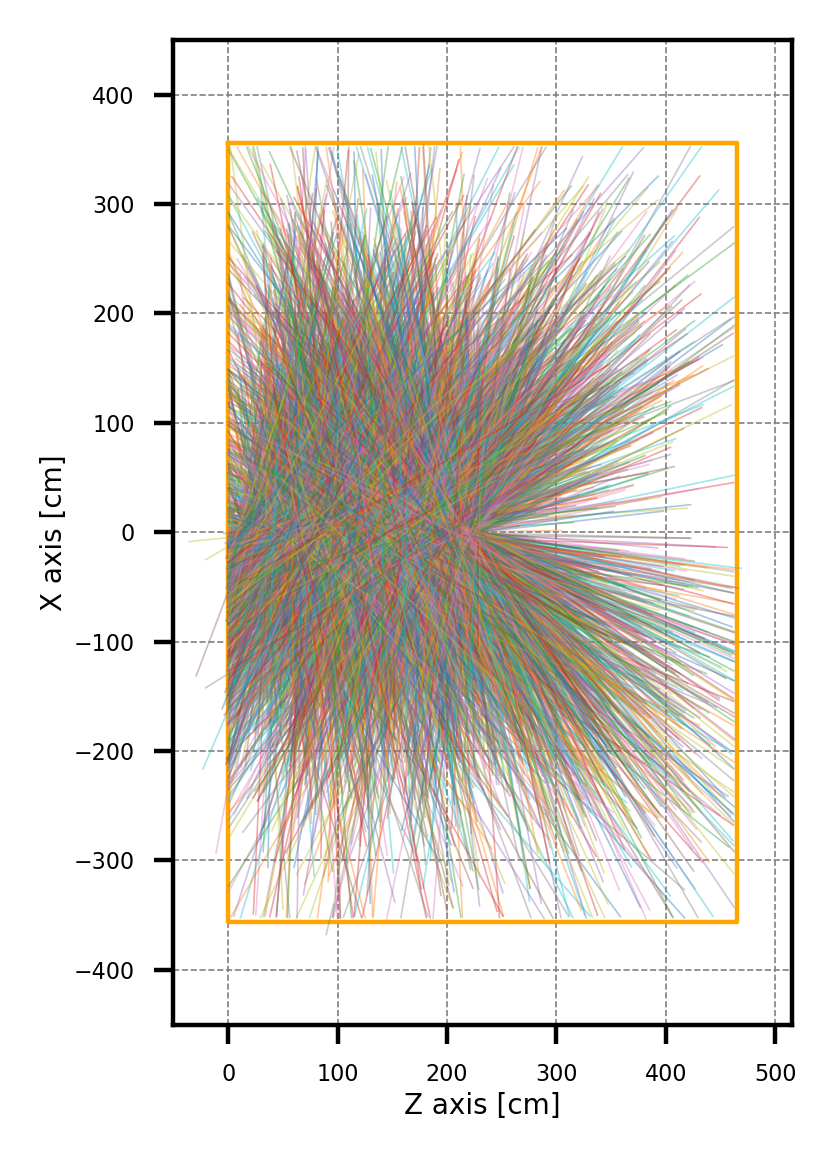

In [ ]:
# Tracks after TPC cuts------
draw_tracks_xz(TPC_events_reco, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


# Check APA1 crossing------
TPC_events_reco_NoAPA1, TPC_events_reco_APA1 = split_tracks_by_APA1_boundaries(
    TPC_events_reco
)

print("TPC_events_reco : ", len(TPC_events_reco))
print("No APA1 crossing: ", len(TPC_events_reco_NoAPA1),
      "({:.2f}%)".format(len(TPC_events_reco_NoAPA1)/len(TPC_events_reco)*100))
print("APA1 crossing   : ", len(TPC_events_reco_APA1),
      "({:.2f}%)".format(len(TPC_events_reco_APA1)/len(TPC_events_reco)*100))

draw_tracks_xz(TPC_events_reco_NoAPA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)
draw_tracks_xz(TPC_events_reco_APA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


<br />
<br />


### Stopping points distributions: X projection and Top View

Decay points distribution (After TPC cut): 
#vals_decayX_NoAPA1:  89082
# of X < 0 :  43845 (49.219%)
# of X >= 0:  45237 (50.781%)

Decay points in 4 APA regions:
# APA1:  491 (0.55%)
# APA2:  43354 (48.67%)
# APA3:  6309 (7.08%)
# APA4:  38928 (43.70%)


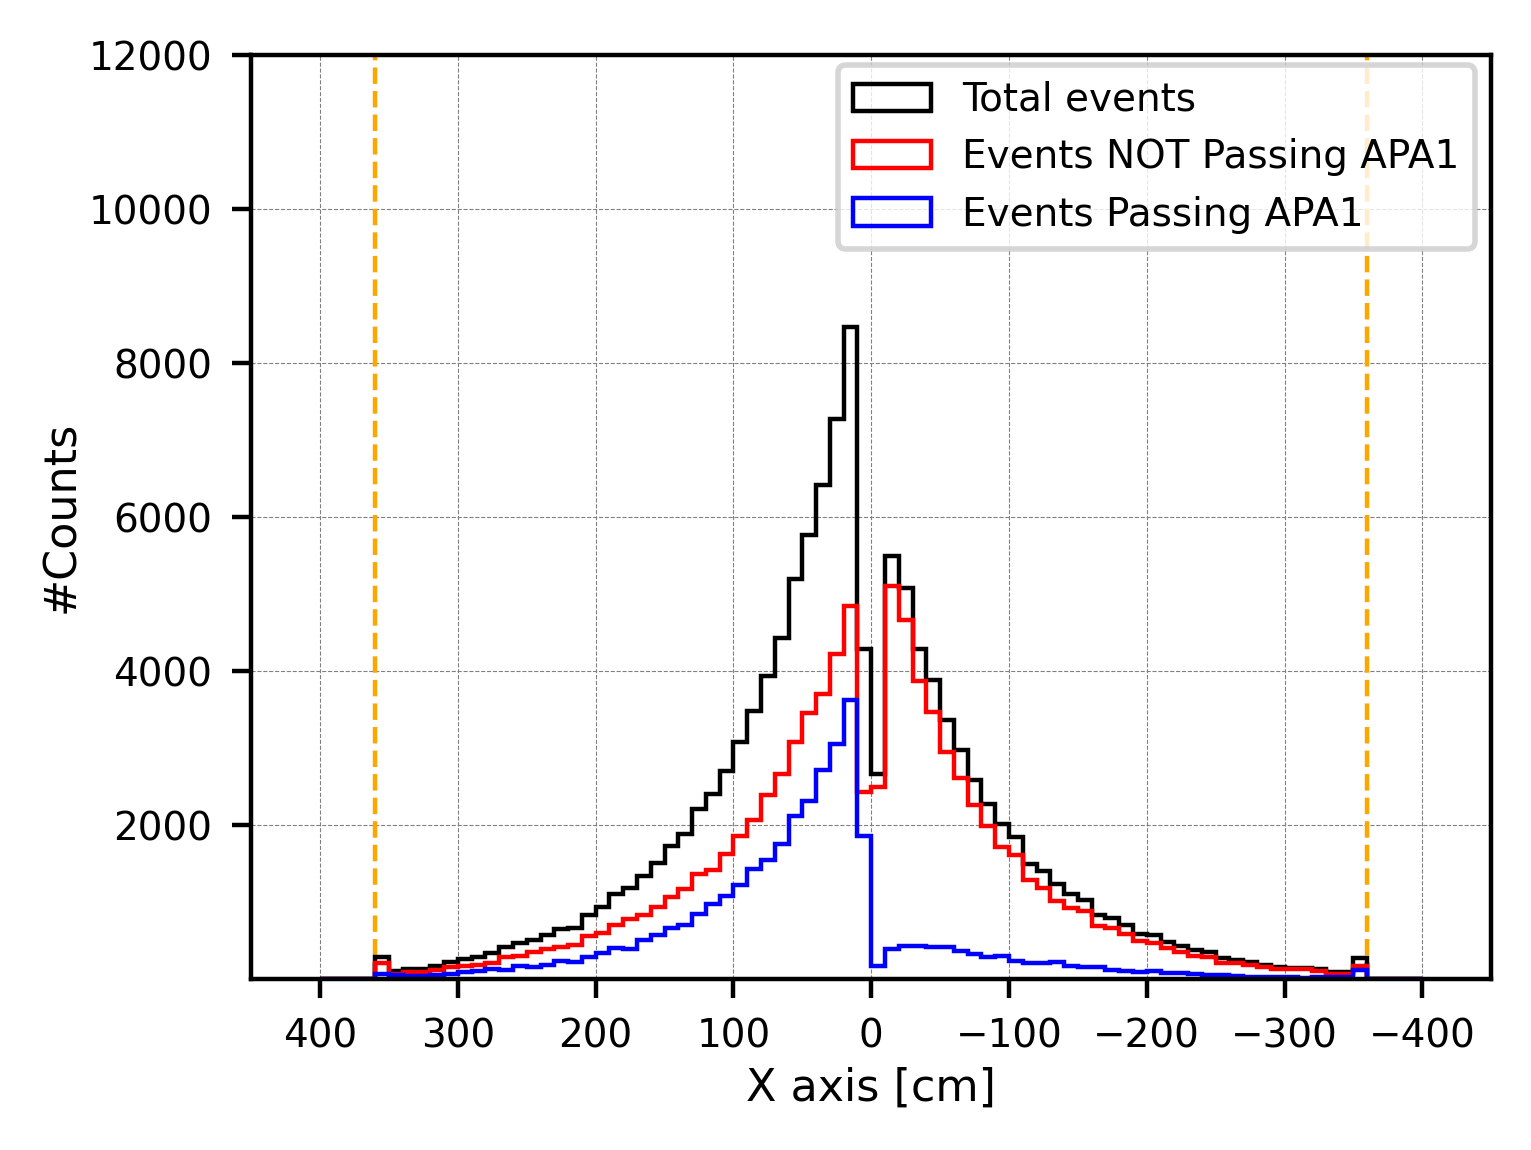

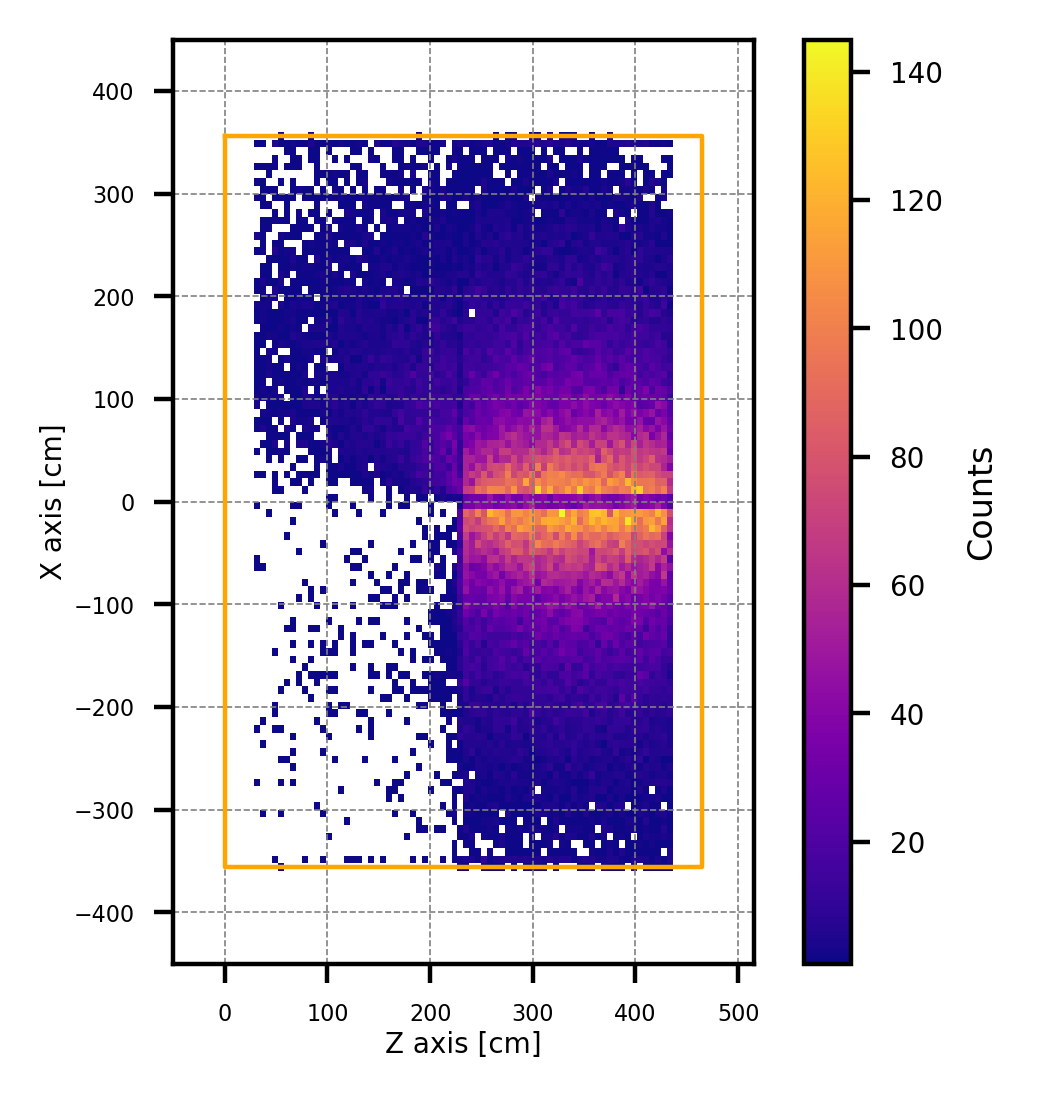

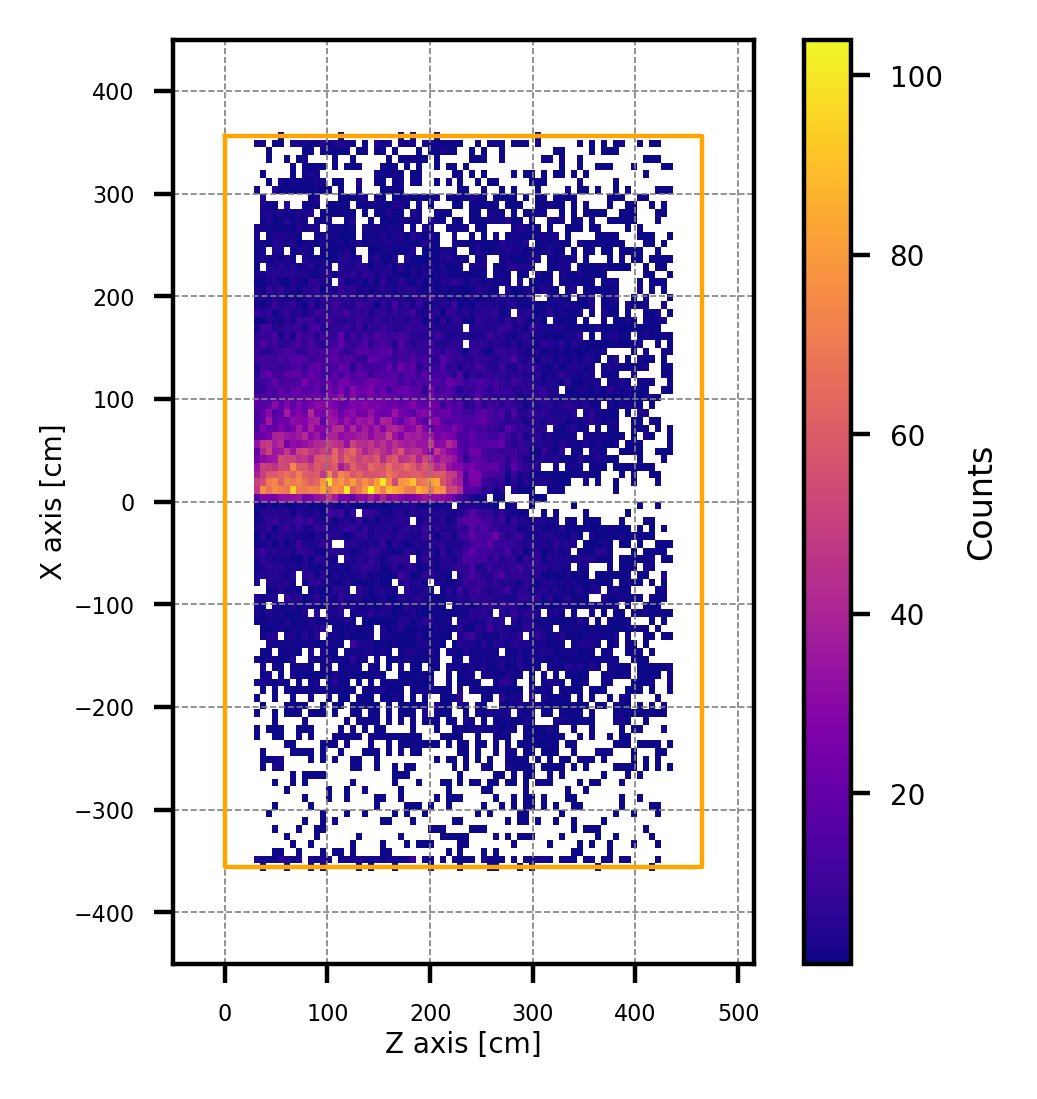

In [ ]:


vals_decayX_NoAPA1 = [ev.decayX_initial for ev in TPC_events_reco_NoAPA1]
vals_decayX_APA1 = [ev.decayX_initial for ev in TPC_events_reco_APA1]
vals_decayZ_NoAPA1 = [ev.decayZ_initial for ev in TPC_events_reco_NoAPA1]
vals_decayZ_APA1 = [ev.decayZ_initial for ev in TPC_events_reco_APA1]




#Calculate the percentage--------------------
#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

vals_decayX_NoAPA1 = np.array(vals_decayX_NoAPA1)
neg_X_noAPA1 = np.sum(vals_decayX_NoAPA1 < 0)
pos_X_noAPA1 = np.sum(vals_decayX_NoAPA1 >= 0)
print("#vals_decayX_NoAPA1: ", len(vals_decayX_NoAPA1))
print("# of X < 0 : ", neg_X_noAPA1, 
      "({:.3f}%)".format(neg_X_noAPA1/len(vals_decayX_NoAPA1)*100))
print("# of X >= 0: ", pos_X_noAPA1, 
      "({:.3f}%)".format(pos_X_noAPA1/len(vals_decayX_NoAPA1)*100))


np.save("decayX_noAPA1Cross_MC.npy", vals_decayX_NoAPA1)



# Decay points in 4 APA regions
# APA1: X <= 0, Z <= 231.266
# APA2: X <= 0, Z >  231.266
# APA3: X >  0, Z <= 231.266
# APA4: X >  0, Z >  231.266

vals_decayZ_NoAPA1 = np.array(vals_decayZ_NoAPA1)

z_split = 231.266
n_total = len(vals_decayX_NoAPA1)

n_apa1 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa2 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 >  z_split))
n_apa3 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa4 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 >  z_split))

print("\nDecay points in 4 APA regions:")
print("# APA1: ", n_apa1, "({:.2f}%)".format(n_apa1 / n_total * 100))
print("# APA2: ", n_apa2, "({:.2f}%)".format(n_apa2 / n_total * 100))
print("# APA3: ", n_apa3, "({:.2f}%)".format(n_apa3 / n_total * 100))
print("# APA4: ", n_apa4, "({:.2f}%)".format(n_apa4 / n_total * 100))






#Decay points distribution:==========================================
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#APA planes---
plt.plot([-360, -360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Total events")
plt.hist(vals_decayX_NoAPA1, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label="Events NOT Passing APA1")
plt.hist(vals_decayX_APA1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label="Events Passing APA1")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 12000)
#plt.yscale('log')
#plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.73, 1.01), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_tpcCut_MC.png', dpi=600, bbox_inches='tight')

plt.show() 





#Z-X plane ploting (Top View) (No passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_NoAPA1, vals_decayX_NoAPA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()






#Z-X plane ploting (Top View) (passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_APA1, vals_decayX_APA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()




